# TimesFM-3 vs. the Market

### **Introduction**

Financial markets are a great place to test whether a forecasting model actually knows something useful. Prices clearly have patterns, but they are also noisy, competitive, and notoriously difficult to predict. A forecast can look impressively sophisticated while still doing worse than an almost absurdly simple alternative: assume that the future price will be the same as the price today.

**TimesFM-3 is Google’s time-series foundation model.** The basic idea is similar to a large language model, except instead of learning patterns in text and predicting what words come next, TimesFM learns patterns across enormous collections of data that change over time and predicts what values are likely to come next. It is designed to work across many kinds of time series rather than being built specifically for financial markets, which is exactly what makes this test interesting: can a general forecasting model recognize anything useful in stocks, bonds, currencies, commodities, and crypto without being specially trained for them?

Our experiment is straightforward. We’ll travel back to different points in financial history, show TimesFM only the prices it could have seen at that moment, and ask it to forecast the future. Because we already know what happened next, we can compare the model’s prediction with reality. More importantly, we can compare it with our deliberately dumb baseline: simply predicting that the price will not change.

We’ll build the experiment one piece at a time. Everything will stay inside this notebook, and every important intermediate result will appear as a table, number, or chart. The goal is not just to get an answer, but to understand exactly how we got there.


## A. Pull the dependencies

Before we touch any financial data, we need the small collection of Python tools that will power the experiment. `yfinance` will give us historical market prices, `pandas` and `NumPy` will let us organize and analyze them, and `Matplotlib` will let us see what is happening rather than staring at raw numbers. `PyTorch` provides the computational machinery underneath TimesFM, while the `timesfm` package gives us the model itself. We’ll also use `tqdm` later to make longer forecasting runs easier to follow.

For now, that is all we need. If the experiment eventually demands more sophisticated statistical tools, we can add them when we actually have a reason to use them.


In [ ]:
# ============================================================
# A. PULL AND IMPORT THE DEPENDENCIES
# ============================================================

%pip install -q yfinance pandas numpy matplotlib tqdm git+https://github.com/google-research/timesfm.git

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from tqdm.auto import tqdm

import torch
import timesfm


# Quick check that our environment is working
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CPU cores:", os.cpu_count())
print("CUDA available:", torch.cuda.is_available())

print("\n✓ Everything is ready.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Python: 3.13.15
PyTorch: 2.11.0+cpu
CPU cores: 2
CUDA available: False

✓ Everything is ready.


## B. Pick our first five markets

Before asking TimesFM to predict anything, we need something to predict. Rather than immediately throwing dozens of tickers at the model, we’ll begin with five markets that behave quite differently from one another: the S&P 500, technology stocks, long-term U.S. Treasury bonds, gold, and Bitcoin. Together they give us a small but varied laboratory—growth, interest rates, a traditional safe-haven asset, and crypto—without making the experiment difficult to follow.

We’ll use `yfinance` to pull their daily historical prices. At this stage we are not modeling anything. We simply want a clean table containing the date and closing price for each asset, and then we’ll look at what we actually downloaded.


In [ ]:
# ============================================================
# B. PICK OUR FIRST FIVE MARKETS
# ============================================================

assets = {
    "SPY": "S&P 500",
    "QQQ": "Nasdaq 100",
    "TLT": "Long-Term U.S. Treasury Bonds",
    "GLD": "Gold",
    "BTC-USD": "Bitcoin"
}

assets

{'SPY': 'S&P 500',
 'QQQ': 'Nasdaq 100',
 'TLT': 'Long-Term U.S. Treasury Bonds',
 'GLD': 'Gold',
 'BTC-USD': 'Bitcoin'}

### Download the history

For each market, we’ll download daily prices beginning in 2010. Bitcoin and some of the ETFs have shorter histories, so they will simply begin whenever data becomes available. We’ll keep only the closing price for now. That is deliberately minimal: TimesFM ultimately needs a sequence of numbers, and the first sequence we want to understand is simply, “What was this asset worth each day?”


In [ ]:
# Download daily prices from 2010 onward

raw_data = yf.download(
    list(assets.keys()),
    start="2010-01-01",
    auto_adjust=False,
    progress=False
)

# Pull out just the closing prices
prices = raw_data["Close"].copy()

# Give the columns human-readable names
prices = prices.rename(columns=assets)

# Show the first few rows
prices.head()

Ticker,Bitcoin,Gold,Nasdaq 100,S&P 500,Long-Term U.S. Treasury Bonds
Date,,,,,
2010-01-04,NaN,109.800003,46.419998,113.330002,89.809998
2010-01-05,NaN,109.699997,46.419998,113.629997,90.389999
2010-01-06,NaN,111.510002,46.139999,113.709999,89.180000
2010-01-07,NaN,110.820000,46.169998,114.190002,89.330002
2010-01-08,NaN,111.370003,46.549999,114.570000,89.290001


## C. What did we actually download?

Before forecasting anything, it is worth stopping to inspect the raw material. Different markets have different histories: SPY goes back decades, while Bitcoin does not; markets also close on different days and occasionally have missing observations. Those differences can quietly create problems later if we ignore them now.

So our first diagnostic is deliberately mundane. For each asset, we’ll ask when its data begins, when it ends, how many daily prices we have, and how many values are missing. This gives us a quick map of the dataset before we start manipulating it.


In [ ]:
# ============================================================
# C. INSPECT THE DATA WE DOWNLOADED
# ============================================================

coverage = pd.DataFrame({
    "First date": prices.apply(lambda x: x.first_valid_index()),
    "Last date": prices.apply(lambda x: x.last_valid_index()),
    "Observations": prices.count(),
    "Missing values": prices.isna().sum()
})

coverage

,First date,Last date,Observations,Missing values
Ticker,,,,
Bitcoin,2014-09-17,2026-09-04,4371,1184
Gold,2010-01-04,2026-09-04,4194,1361
Nasdaq 100,2010-01-04,2026-09-04,4194,1361
S&P 500,2010-01-04,2026-09-04,4194,1361
Long-Term U.S. Treasury Bonds,2010-01-04,2026-09-04,4194,1361


### Take a look at the price histories

A table can tell us whether the data exists, but a chart is often better at revealing whether something looks obviously wrong. Because these assets live on completely different price scales, we won’t compare them directly yet. For now, we’ll simply give each market its own chart and look at the histories we are about to hand to TimesFM.

*What do the missing values mean?*

The large number of missing values initially looks worrying, but most of it is structural rather than missing data. Bitcoin trades seven days a week, while the ETFs trade only when their markets are open. Because all five assets share the same date index, weekends appear as rows once Bitcoin begins trading, leaving blank values for stocks, bonds, and gold. Bitcoin has the opposite problem at the beginning of the dataset: our history starts in 2010, several years before the Bitcoin price series begins.

We will therefore **not fill these gaps**. When we model each asset, we will use only that asset's actual observations. Filling weekends with Friday's closing price would create artificial zero-movement days that never occurred in the traded series.


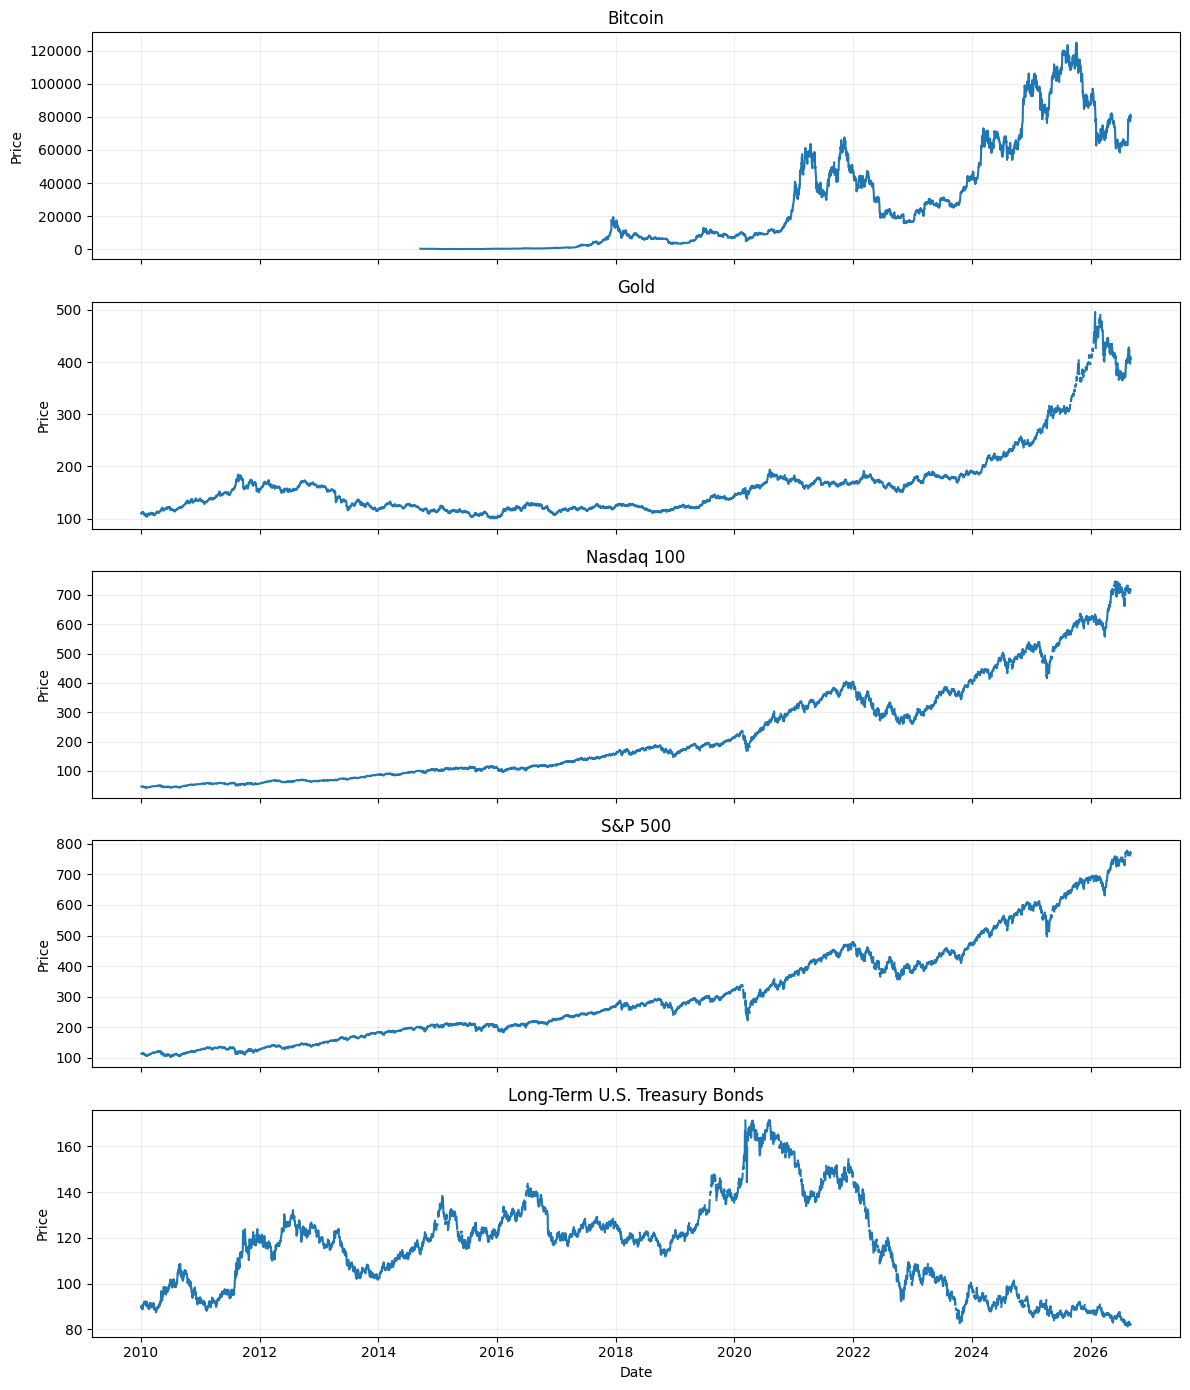

In [ ]:
# Plot each asset separately so their very different price scales
# do not obscure one another.

fig, axes = plt.subplots(
    len(prices.columns),
    1,
    figsize=(12, 14),
    sharex=True
)

for ax, asset in zip(axes, prices.columns):
    ax.plot(prices.index, prices[asset])
    ax.set_title(asset)
    ax.set_ylabel("Price")
    ax.grid(alpha=0.2)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## D. Load TimesFM-3

So far, we have done nothing with AI. We have simply assembled five price histories and made sure we understand what is in them. Now we can bring in TimesFM-3 itself.

Loading the model does not make a forecast yet. It downloads Google's pretrained model weights and places the model in memory, ready to receive a sequence of numbers. In the next step, we will give it one very concrete task: look at the recent history of the S&P 500 and predict the next 20 trading days.

In [ ]:
# ============================================================
# D. LOAD TIMESFM-3
# ============================================================

from timesfm3 import TimesFM3Forecaster

forecaster = TimesFM3Forecaster.from_pretrained(
    "google/timesfm-3.0-pytorch"
)

print("✓ TimesFM-3 is loaded and ready.")

config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.32GB            

model.safetensors: downloading bytes:           |  0.00B            

✓ TimesFM-3 is loaded and ready.


## E. Our first forecast

Now we can finally ask TimesFM a real question.

We’ll start with the S&P 500 and create a simple historical test. We’ll take the most recent 532 trading days in our dataset, show TimesFM only the first 512, and hide the final 20. In other words, the model gets roughly two years of market history and then has to predict the next 20 trading days.

This is just one episode, so it cannot tell us whether TimesFM is generally good at forecasting markets. Its purpose is simpler: to make sure we understand exactly what goes into the model, what comes out, and how a forecast compares with reality.

In [ ]:
# ============================================================
# E. PREPARE OUR FIRST FORECAST
# ============================================================

spy = prices["S&P 500"].dropna()

context_length = 512
horizon = 20

# The 512 prices TimesFM is allowed to see
context_series = spy.iloc[-(context_length + horizon):-horizon]

# The 20 future prices we hide from TimesFM
actual_series = spy.iloc[-horizon:]

context = context_series.to_numpy(dtype=np.float32)
actual = actual_series.to_numpy(dtype=float)

print("Last date TimesFM can see:", context_series.index[-1].date())
print("Last visible S&P 500 price:", round(context[-1], 2))
print("Observations shown to TimesFM:", len(context))
print("Future observations hidden:", len(actual))

Last date TimesFM can see: 2026-08-07
Last visible S&P 500 price: 773.26
Observations shown to TimesFM: 512
Future observations hidden: 20


In [ ]:
output = forecaster.predict(
    context=context,
    horizon=horizon
)

forecast = np.asarray(output.forecast).squeeze()

print("TimesFM returned", len(forecast), "forecast values.")
print(np.round(forecast, 2))

TimesFM returned 20 forecast values.
[772.72 771.96 771.23 770.75 769.9  769.44 769.07 768.97 768.87 768.67
 768.71 768.73 768.83 768.97 769.15 769.36 769.5  769.68 769.76 770.05]


In [ ]:
# ============================================================
# REVEAL THE FUTURE
# ============================================================

comparison = pd.DataFrame({
    "Actual S&P 500": actual,
    "TimesFM Forecast": forecast
}, index=actual_series.index)

comparison.index.name = "Date"

comparison.round(2)

,Actual S&P 500,TimesFM Forecast
Date,,
2026-08-10,773.03,772.719971
2026-08-11,770.56,771.960022
2026-08-12,772.49,771.229980
2026-08-13,777.88,770.750000
2026-08-14,776.34,769.900024
2026-08-17,772.67,769.440002
2026-08-18,767.45,769.070007
2026-08-19,769.06,768.969971
2026-08-20,762.60,768.869995


### First impression

TimesFM's first forecast is much smoother than the market itself. Rather than trying to predict every daily jump and dip, the model expects the S&P 500 to drift gradually downward and then settle around roughly the same level.

The actual market is noisier, but it spends much of the period in the same broad range as the forecast. That makes the prediction look reasonably plausible by eye. The important question, though, is not whether the forecast looks sensible. It is whether it does better than an extremely simple alternative: assume that the market simply stays at its last observed price.

In [ ]:
# ============================================================
# ADD THE PERSISTENCE BASELINE
# ============================================================

# Persistence predicts that every future price
# will equal the last price we observed.

last_known_price = context[-1]

comparison["Persistence"] = last_known_price

comparison.round(2)

,Actual S&P 500,TimesFM Forecast,Persistence
Date,,,
2026-08-10,773.03,772.719971,773.26001
2026-08-11,770.56,771.960022,773.26001
2026-08-12,772.49,771.229980,773.26001
2026-08-13,777.88,770.750000,773.26001
2026-08-14,776.34,769.900024,773.26001
2026-08-17,772.67,769.440002,773.26001
2026-08-18,767.45,769.070007,773.26001
2026-08-19,769.06,768.969971,773.26001
2026-08-20,762.60,768.869995,773.26001


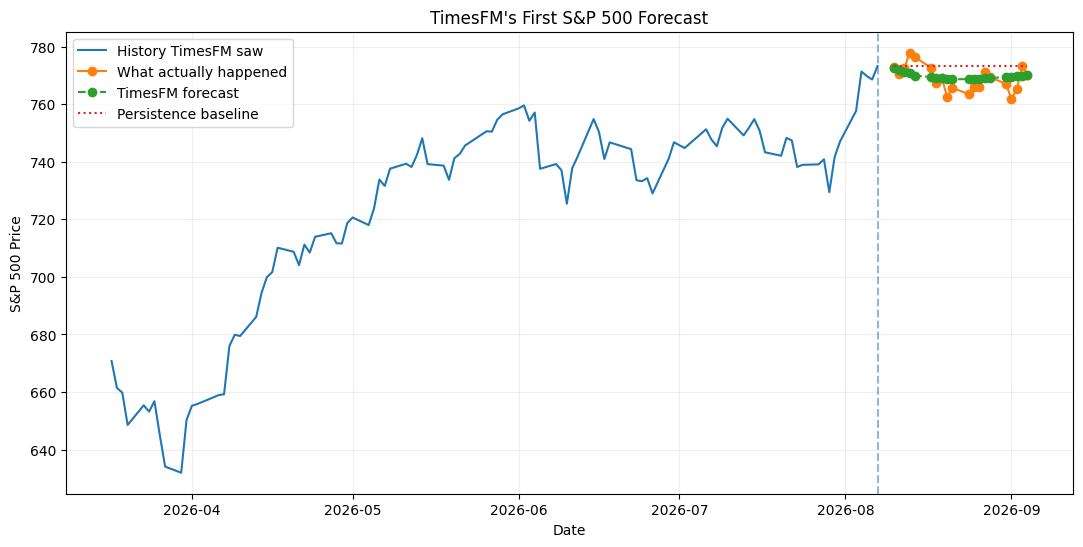

In [ ]:
# ============================================================
# PLOT THE FORECAST AGAINST REALITY
# ============================================================

history_to_plot = context_series.iloc[-100:]

plt.figure(figsize=(13, 6))

plt.plot(
    history_to_plot.index,
    history_to_plot.values,
    label="History TimesFM saw"
)

plt.plot(
    comparison.index,
    comparison["Actual S&P 500"],
    marker="o",
    label="What actually happened"
)

plt.plot(
    comparison.index,
    comparison["TimesFM Forecast"],
    marker="o",
    linestyle="--",
    label="TimesFM forecast"
)

plt.plot(
    comparison.index,
    comparison["Persistence"],
    linestyle=":",
    label="Persistence baseline"
)

plt.axvline(
    context_series.index[-1],
    linestyle="--",
    alpha=0.5
)

plt.title("TimesFM's First S&P 500 Forecast")
plt.ylabel("S&P 500 Price")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### What happened?

Our first forecast passes the most basic sanity test: TimesFM keeps the S&P 500 in roughly the right neighborhood rather than producing an obviously implausible trajectory. But it also smooths away much of what actually happened. The market moved sharply up and down over the following weeks, while TimesFM settled into a much narrower range.

That makes this first example interesting but inconclusive. TimesFM appears to have made a reasonable estimate of the future **level** of the market, but it did not anticipate much of the short-term volatility. The real test is whether this smoother forecast was actually more accurate than our deliberately simple persistence baseline.


In [ ]:
# ============================================================
# SCORE OUR FIRST FORECAST
# ============================================================

# Our deliberately dumb competitor:
# "The price in the future will just equal the price today."
persistence = np.full(len(actual), context[-1])

# Average absolute forecasting error
timesfm_mae = np.mean(np.abs(forecast - actual))
persistence_mae = np.mean(np.abs(persistence - actual))

# How much does TimesFM improve on persistence?
skill = 1 - (timesfm_mae / persistence_mae)

print(f"TimesFM MAE:      {timesfm_mae:.2f}")
print(f"Persistence MAE:  {persistence_mae:.2f}")
print(f"TimesFM skill:    {skill:+.1%}")

TimesFM MAE:      3.10
Persistence MAE:  4.97
TimesFM skill:    +37.6%


### What happened?

In this first historical test, TimesFM beat our simple persistence baseline by a surprisingly large margin. Its predictions were off by an average of 3.10 S&P 500 points, compared with 4.97 points for simply assuming that the market would remain at its last observed price. Put differently, TimesFM reduced the baseline's forecasting error by **37.6%**.

That is encouraging, but it is only one 20-day episode, and there is a deeper question about what kind of accuracy we actually care about. A trader does not necessarily need to predict every individual day's closing price. The relevant horizon depends on how often we expect to make decisions. A one-day forecast is most relevant to **day trading**: can the model tell us anything useful about tomorrow? A five-day forecast is closer to **weekly positioning**, while a twenty-day forecast is closer to a **monthly trading or allocation decision**. TimesFM might be mediocre at predicting each daily wiggle but still be useful if it can anticipate where the market is heading over a week or a month.

There is also an important difference between a **forecasting baseline** and a **trading strategy**. Persistence — predicting that the future price will equal today's price — is a useful statistical benchmark because financial prices are highly persistent and it is surprisingly difficult to beat. But it is not really an investment strategy. It gives us no reason to buy, sell, or change a position. Once we begin asking whether TimesFM's forecasts have economic value, we will need to compare them with things an investor could actually do, such as simply buying and holding the asset or following a simple trend.

So this first result is best understood as a proof of concept. TimesFM produced a sensible forecast and, in this particular episode, substantially beat a difficult statistical baseline. The next step is to repeat the experiment across many points in history and ask whether that advantage survives at the horizons that correspond to real decisions: **one day, one week, and one month**.

## F. Replay the experiment through history

One successful forecast is interesting, but it could easily be luck. To find out whether TimesFM has any repeatable skill, we need to recreate the same experiment at many different points in history.

At each historical starting point, we will give TimesFM the previous 512 S&P 500 prices and ask it to forecast the next 20 trading days. We can then inspect three different decision horizons from the same forecast: tomorrow, roughly one week from now, and roughly one month from now.

This gives us a miniature time machine. At every starting date, the model sees only information that would have been available at that moment. We then reveal the future and record how well it did compared with persistence.

To keep this first replay manageable, we will make a new forecast roughly once per month rather than every trading day.

In [ ]:
# ============================================================
# F. SET UP THE HISTORICAL REPLAY
# ============================================================

horizons = {
    "1 Day": 1,
    "1 Week": 5,
    "1 Month": 20
}

context_length = 512
max_horizon = 20

# Make one forecast roughly every 20 trading days.
# Start with the last five years so this first run stays manageable.
eligible = spy.loc["2021-01-01":].index

origin_positions = []

for date in eligible[::20]:
    position = spy.index.get_loc(date)

    # We need 512 observations before the origin
    # and 20 observations after it.
    if position >= context_length and position + max_horizon < len(spy):
        origin_positions.append(position)

print("Historical forecast dates:", len(origin_positions))
print("First:", spy.index[origin_positions[0]].date())
print("Last:", spy.index[origin_positions[-1]].date())

Historical forecast dates: 71
First: 2021-01-04
Last: 2026-08-03


### Make the 71 historical forecasts

Now we repeat our original experiment 71 times. At each point, TimesFM receives the previous 512 trading days and forecasts the next 20. We will make only one model forecast at each starting point, then read the prediction at day 1, day 5, and day 20 from that same forecast.

For each horizon, we will keep three things: what TimesFM predicted, what actually happened, and what persistence would have predicted. We are still not drawing conclusions yet — this cell simply creates the historical record that the next analyses will use.

In [ ]:
# ============================================================
# RUN THE HISTORICAL REPLAY
# ============================================================

results = []

for pos in tqdm(origin_positions, desc="Historical TimesFM forecasts"):

    # The 512 observations TimesFM is allowed to see
    context_series_i = spy.iloc[pos - context_length:pos]
    context_i = context_series_i.to_numpy(dtype=np.float32)

    # Last price known at the moment of the forecast
    last_known_price_i = float(context_i[-1])

    # The actual forecast origin is the final visible trading day
    forecast_origin = context_series_i.index[-1]

    # Ask TimesFM for the full next 20 trading days once
    output_i = forecaster.predict(
        context=context_i,
        horizon=max_horizon
    )

    forecast_i = np.asarray(output_i.forecast).squeeze()

    # Read day 1, day 5, and day 20 from the same forecast
    for horizon_name, h in horizons.items():

        target_pos = pos + h - 1

        results.append({
            "Forecast Origin": forecast_origin,
            "Horizon": horizon_name,
            "Days Ahead": h,
            "Last Known Price": last_known_price_i,
            "TimesFM Forecast": float(forecast_i[h - 1]),
            "Actual Price": float(spy.iloc[target_pos]),
            "Target Date": spy.index[target_pos]
        })

historical_results = pd.DataFrame(results)

print("\n✓ Historical replay complete.")
print("Forecast origins:", len(origin_positions))
print("Rows of results:", len(historical_results))

historical_results.head(9).round(2)

Historical TimesFM forecasts:   0%|          | 0/71 [00:00<?, ?it/s]


✓ Historical replay complete.
Forecast origins: 71
Rows of results: 213


,Forecast Origin,Horizon,Days Ahead,Last Known Price,TimesFM Forecast,Actual Price,Target Date
0,2020-12-31,1 Day,1,373.88,373.27,368.79,2021-01-04
1,2020-12-31,1 Week,5,373.88,373.73,381.26,2021-01-08
2,2020-12-31,1 Month,20,373.88,376.40,376.23,2021-02-01
3,2021-02-01,1 Day,1,376.23,376.74,381.55,2021-02-02
4,2021-02-01,1 Week,5,376.23,379.23,390.51,2021-02-08
5,2021-02-01,1 Month,20,376.23,383.93,386.54,2021-03-02
6,2021-03-02,1 Day,1,386.54,387.18,381.42,2021-03-03
7,2021-03-02,1 Week,5,386.54,389.80,387.17,2021-03-09
8,2021-03-02,1 Month,20,386.54,396.53,394.73,2021-03-30


## G. Does TimesFM actually forecast better?

We now have 71 historical forecast dates and three predictions at each one: one day, one week, and one month ahead. Instead of inspecting individual episodes, we can finally summarize how well TimesFM performed across the whole replay.

For each horizon, we will calculate TimesFM's mean absolute error (MAE) and compare it with persistence — the forecast that simply assumes the price never moves. We will also calculate the same "skill" score we used earlier: the percentage by which TimesFM reduces persistence's error.

Because exact price accuracy is not our only concern, we will also ask a simpler directional question: when TimesFM predicted that the S&P 500 would be higher or lower at the end of the horizon, how often was it right?

In [ ]:
# ============================================================
# G. FORECAST QUALITY ACROSS HISTORY
# ============================================================

hr = historical_results.copy()

# Forecast errors
hr["TimesFM Error"] = (
    hr["TimesFM Forecast"] - hr["Actual Price"]
).abs()

hr["Persistence Error"] = (
    hr["Last Known Price"] - hr["Actual Price"]
).abs()

# Predicted and actual percentage moves
hr["Predicted Move"] = (
    hr["TimesFM Forecast"] / hr["Last Known Price"] - 1
)

hr["Actual Move"] = (
    hr["Actual Price"] / hr["Last Known Price"] - 1
)

# Did TimesFM get the direction right?
hr["Direction Correct"] = (
    np.sign(hr["Predicted Move"]) ==
    np.sign(hr["Actual Move"])
)

forecast_summary = (
    hr.groupby(["Horizon", "Days Ahead"])
      .agg(
          Forecasts=("Actual Price", "size"),
          TimesFM_MAE=("TimesFM Error", "mean"),
          Persistence_MAE=("Persistence Error", "mean"),
          Direction_Accuracy=("Direction Correct", "mean")
      )
      .reset_index()
      .sort_values("Days Ahead")
)

forecast_summary["Skill"] = (
    1 -
    forecast_summary["TimesFM_MAE"] /
    forecast_summary["Persistence_MAE"]
)

# Make the table easier to read
display_table = forecast_summary.copy()

display_table["TimesFM_MAE"] = display_table["TimesFM_MAE"].round(2)
display_table["Persistence_MAE"] = display_table["Persistence_MAE"].round(2)
display_table["Skill"] = (display_table["Skill"] * 100).round(1)
display_table["Direction_Accuracy"] = (
    display_table["Direction_Accuracy"] * 100
).round(1)

display_table = display_table.rename(columns={
    "TimesFM_MAE": "TimesFM MAE",
    "Persistence_MAE": "Persistence MAE",
    "Skill": "Skill %",
    "Direction_Accuracy": "Direction Accuracy %"
})

display_table

,Horizon,Days Ahead,Forecasts,TimesFM MAE,Persistence MAE,Direction Accuracy %,Skill %
0,1 Day,1,71,3.63,3.64,62.0,0.5
2,1 Week,5,71,10.03,9.48,49.3,-5.8
1,1 Month,20,71,15.41,16.32,69.0,5.6


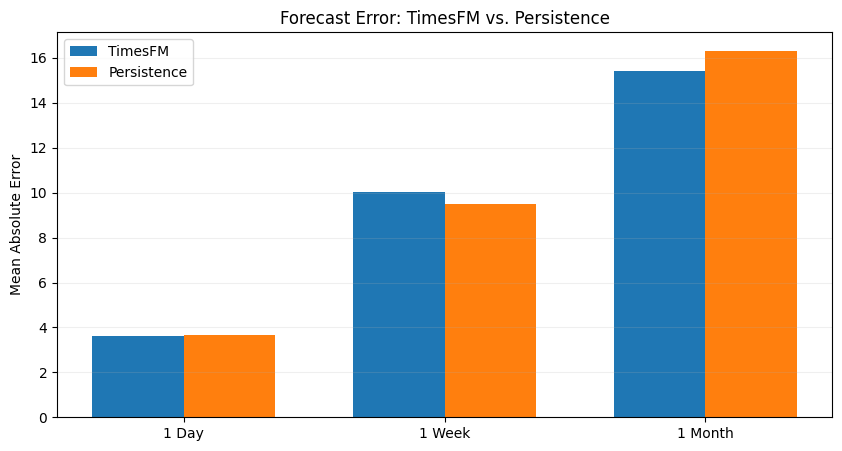

In [ ]:
# ============================================================
# PLOT: TIMESFM VS PERSISTENCE
# ============================================================

x = np.arange(len(forecast_summary))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    forecast_summary["TimesFM_MAE"],
    width,
    label="TimesFM"
)

plt.bar(
    x + width/2,
    forecast_summary["Persistence_MAE"],
    width,
    label="Persistence"
)

plt.xticks(x, forecast_summary["Horizon"])
plt.ylabel("Mean Absolute Error")
plt.title("Forecast Error: TimesFM vs. Persistence")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()

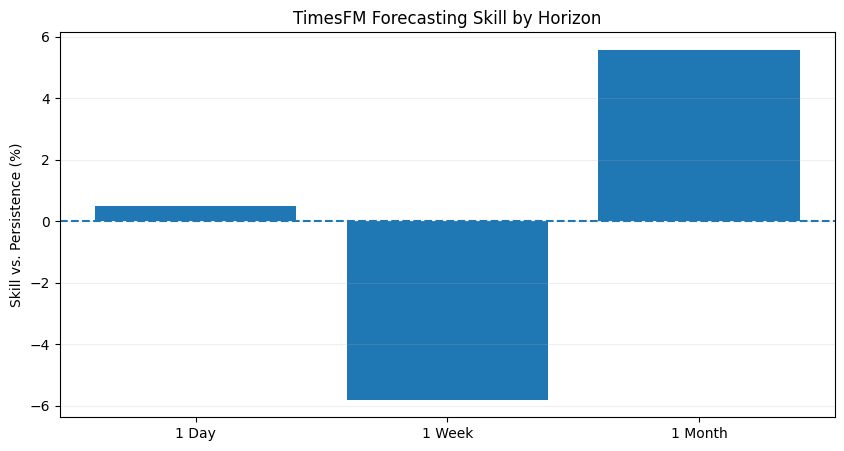

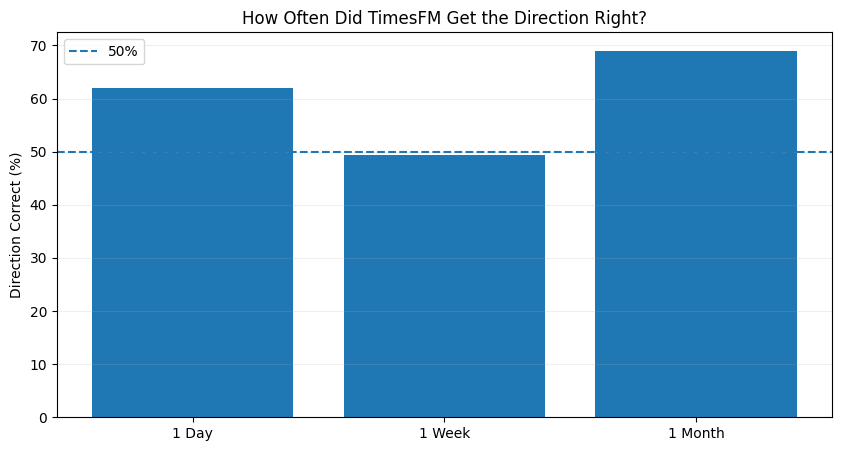

In [ ]:
# ============================================================
# PLOT: WHERE DOES TIMESFM HAVE SKILL?
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    forecast_summary["Horizon"],
    forecast_summary["Skill"] * 100
)

plt.axhline(0, linestyle="--")

plt.ylabel("Skill vs. Persistence (%)")
plt.title("TimesFM Forecasting Skill by Horizon")
plt.grid(axis="y", alpha=0.2)

plt.show()


plt.figure(figsize=(10, 5))

plt.bar(
    forecast_summary["Horizon"],
    forecast_summary["Direction_Accuracy"] * 100
)

plt.axhline(50, linestyle="--", label="50%")

plt.ylabel("Direction Correct (%)")
plt.title("How Often Did TimesFM Get the Direction Right?")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()

## H. Does the amount of history matter?

Our first TimesFM experiments gave the model roughly two years of historical prices. But that choice was arbitrary. Perhaps predicting tomorrow depends mostly on the recent market regime. Or perhaps TimesFM benefits from seeing several years of market behavior before deciding what comes next.

To isolate this question, we will hold everything else fixed. At the same 71 historical points, TimesFM will always be asked the same task: **predict the next trading day's S&P 500 closing price**. The only thing we will change is how much history it receives.

We will test approximately three months, six months, one year, two years, and five years of prior prices. This gives us a controlled experiment in a single variable: **how much of the past should TimesFM see when forecasting tomorrow?**

In [ ]:
# ============================================================
# H. DOES THE AMOUNT OF HISTORY MATTER?
# One-day forecasting only
# ============================================================

lookbacks = {
    "3 Months": 63,
    "6 Months": 126,
    "1 Year": 252,
    "2 Years": 504,
    "5 Years": 1260
}

one_day_lookback_results = []

for lookback_name, lookback_days in lookbacks.items():

    print(f"\nTesting {lookback_name}")

    for pos in tqdm(origin_positions, desc=lookback_name):

        if pos < lookback_days:
            continue

        context_series_i = spy.iloc[
            pos - lookback_days:pos
        ]

        context_i = context_series_i.to_numpy(
            dtype=np.float32
        )

        last_known_price = float(context_i[-1])

        output = forecaster.predict(
            context=context_i,
            horizon=1
        )

        forecast = float(
            np.asarray(output.forecast).squeeze()
        )

        actual = float(spy.iloc[pos])

        one_day_lookback_results.append({
            "Forecast Origin": context_series_i.index[-1],
            "Lookback": lookback_name,
            "Lookback Days": lookback_days,
            "Last Known Price": last_known_price,
            "TimesFM Forecast": forecast,
            "Actual Price": actual
        })

one_day_lookback_results = pd.DataFrame(
    one_day_lookback_results
)

print("\nRows:", len(one_day_lookback_results))
one_day_lookback_results.head()


Testing 3 Months


3 Months:   0%|          | 0/71 [00:00<?, ?it/s]


Testing 6 Months


6 Months:   0%|          | 0/71 [00:00<?, ?it/s]


Testing 1 Year


...

2 Years:   0%|          | 0/71 [00:00<?, ?it/s]


Testing 5 Years


5 Years:   0%|          | 0/71 [00:00<?, ?it/s]


Rows: 355


,Forecast Origin,Lookback,Lookback Days,Last Known Price,TimesFM Forecast,Actual Price
0,2020-12-31,3 Months,63,373.880005,373.063385,368.790009
1,2021-02-01,3 Months,63,376.230011,378.999176,381.549988
2,2021-03-02,3 Months,63,386.540009,388.031036,381.420013
3,2021-03-30,3 Months,63,394.730011,394.826111,396.329987
4,2021-04-28,3 Months,63,417.399994,417.864532,420.059998


###Which amount of history worked best?

We now have five versions of the same historical experiment. At every forecast date, TimesFM was asked the same question about the same future: what will the S&P 500 close at on the next trading day? The only thing that changed was how much history it was allowed to see.

We can therefore ask whether one lookback window performs consistently better than the others. We will compare both exact price accuracy and directional accuracy. Our main measure of price accuracy will be skill relative to persistence: how much each lookback improves — or worsens — the error of the simple “tomorrow’s price will be the same as today’s” forecast.

In [ ]:
lb1 = one_day_lookback_results.copy()

lb1["TimesFM Error"] = (
    lb1["TimesFM Forecast"] -
    lb1["Actual Price"]
).abs()

lb1["Persistence Error"] = (
    lb1["Last Known Price"] -
    lb1["Actual Price"]
).abs()

lb1["Predicted Move"] = (
    lb1["TimesFM Forecast"] /
    lb1["Last Known Price"] - 1
)

lb1["Actual Move"] = (
    lb1["Actual Price"] /
    lb1["Last Known Price"] - 1
)

lb1["Direction Correct"] = (
    np.sign(lb1["Predicted Move"]) ==
    np.sign(lb1["Actual Move"])
)

one_day_summary = (
    lb1.groupby(["Lookback", "Lookback Days"])
       .agg(
           Forecasts=("Actual Price", "size"),
           TimesFM_MAE=("TimesFM Error", "mean"),
           Persistence_MAE=("Persistence Error", "mean"),
           Direction_Accuracy=("Direction Correct", "mean")
       )
       .reset_index()
)

one_day_summary["Skill"] = (
    1 -
    one_day_summary["TimesFM_MAE"] /
    one_day_summary["Persistence_MAE"]
)

one_day_summary = one_day_summary.sort_values(
    "Lookback Days"
)

display_table = one_day_summary.copy()

display_table["TimesFM MAE"] = (
    display_table["TimesFM_MAE"].round(2)
)

display_table["Persistence MAE"] = (
    display_table["Persistence_MAE"].round(2)
)

display_table["Skill %"] = (
    display_table["Skill"] * 100
).round(1)

display_table["Direction Accuracy %"] = (
    display_table["Direction_Accuracy"] * 100
).round(1)

display(
    display_table[[
        "Lookback",
        "Forecasts",
        "TimesFM MAE",
        "Persistence MAE",
        "Skill %",
        "Direction Accuracy %"
    ]]
)

,Lookback,Forecasts,TimesFM MAE,Persistence MAE,Skill %,Direction Accuracy %
2,3 Months,71,3.89,3.64,-6.6,52.1
4,6 Months,71,3.60,3.64,1.1,53.5
0,1 Year,71,3.65,3.64,-0.2,54.9
1,2 Years,71,3.63,3.64,0.4,63.4
3,5 Years,71,3.71,3.64,-1.8,50.7


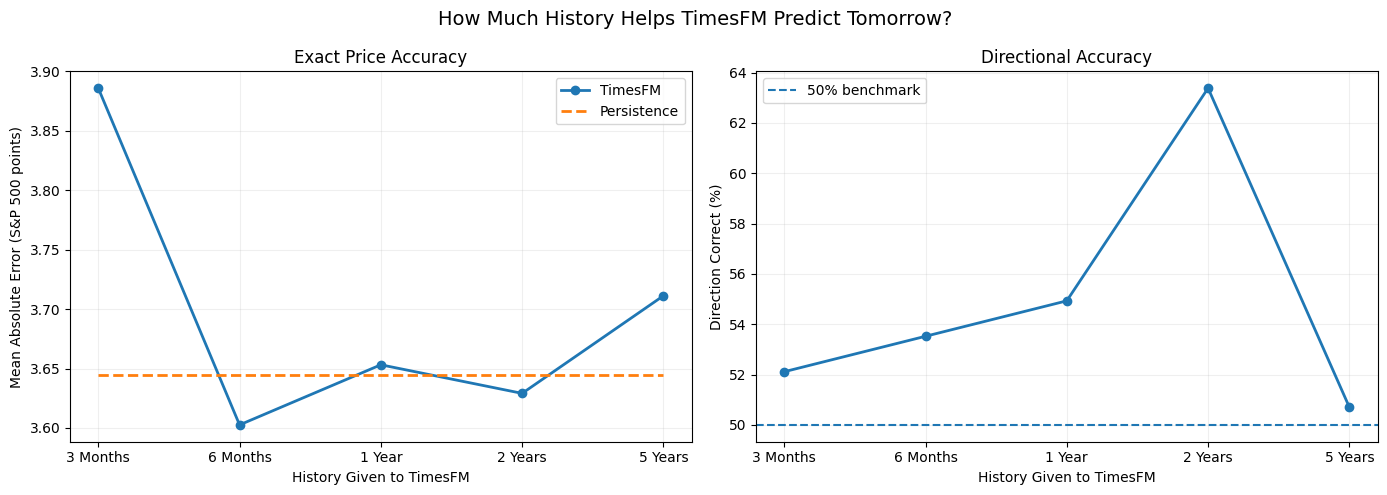

In [ ]:
# ============================================================
# ONE-DAY PERFORMANCE BY LOOKBACK
# Exact price accuracy vs. directional accuracy
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# LEFT: Mean Absolute Error
# ------------------------------------------------------------

axes[0].plot(
    one_day_summary["Lookback"],
    one_day_summary["TimesFM_MAE"],
    marker="o",
    linewidth=2,
    label="TimesFM"
)

axes[0].plot(
    one_day_summary["Lookback"],
    one_day_summary["Persistence_MAE"],
    linestyle="--",
    linewidth=2,
    label="Persistence"
)

axes[0].set_ylabel("Mean Absolute Error (S&P 500 points)")
axes[0].set_xlabel("History Given to TimesFM")
axes[0].set_title("Exact Price Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.2)


# ------------------------------------------------------------
# RIGHT: Directional Accuracy
# ------------------------------------------------------------

axes[1].plot(
    one_day_summary["Lookback"],
    one_day_summary["Direction_Accuracy"] * 100,
    marker="o",
    linewidth=2
)

axes[1].axhline(
    50,
    linestyle="--",
    label="50% benchmark"
)

axes[1].set_ylabel("Direction Correct (%)")
axes[1].set_xlabel("History Given to TimesFM")
axes[1].set_title("Directional Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.suptitle(
    "How Much History Helps TimesFM Predict Tomorrow?",
    fontsize=14
)

plt.tight_layout()
plt.show()

### What happened?

The two plots tell slightly different stories about what counts as a good forecast.

On **exact price accuracy**, there is no simple pattern in which giving TimesFM more history steadily improves its one-day prediction. Performance peaks in the middle of the range. Six months of history produces the lowest mean absolute error at 3.60 S&P 500 points, slightly better than the persistence benchmark of 3.64. The two-year context is close behind at 3.63, while one year is effectively tied with persistence and five years performs slightly worse. The shortest three-month context is clearly the weakest, increasing error by 6.6% relative to persistence.

The differences are modest. Apart from the three-month window, every TimesFM configuration lands in a narrow band of roughly 3.60 to 3.71 points of average error. So the left-hand plot does not suggest that one lookback window dramatically improves TimesFM's ability to predict tomorrow's exact closing price. Six months wins empirically, but only by a small margin.

The **directional-accuracy** plot is much more striking. With two years of history, TimesFM correctly predicts whether the S&P 500 will finish above or below today's price on 63.4% of the tested days. That is substantially higher than the other lookbacks, even though the two-year model does not have the lowest MAE.

These results illustrate why the two metrics should be kept separate. The six-month model can achieve a slightly lower MAE by keeping the magnitude of its errors relatively small, even when it gets the direction wrong more often. The two-year model, meanwhile, gets the direction right much more frequently but can still make larger errors about how far the market will move. A forecast can therefore be better at predicting **where the price will land** without being better at predicting **which direction it will move**, and vice versa.

With only 71 historical forecasts, these differences remain suggestive rather than definitive. The strongest conclusions for now are that very short context appears unhelpful, six months performs marginally best on exact price accuracy, and two years stands out on directional accuracy. The next question is whether these patterns survive when we change how far into the future TimesFM is evaluated.

## I. Does the best lookback depend on how far ahead we forecast?

The previous experiment held the forecasting task fixed at one day and varied only how much historical context TimesFM received. That gave us some evidence that the amount of useful history matters — particularly for predicting direction.

Now we turn the second knob: **how far into the future are we trying to see?**

We will repeat the five lookback conditions, but this time ask TimesFM to generate a longer forecast path. We will evaluate that path after one trading day, one week, one month, three months, and six months.

To keep the comparison fair, we will use only historical forecast dates for which all six months of future data are already available. Every cell in the resulting grid will therefore represent the same set of historical episodes.

The result is a two-dimensional experiment: **how much history should TimesFM see, and at what forecast horizon does that history prove most useful?**

In [ ]:
# ============================================================
# I. LOOKBACK × LOOK-FORWARD EXPERIMENT
# ============================================================

lookbacks = {
    "3 Months": 63,
    "6 Months": 126,
    "1 Year": 252,
    "2 Years": 504,
    "5 Years": 1260
}

forward_horizons = {
    "1 Day": 1,
    "1 Week": 5,
    "1 Month": 20,
    "3 Months": 60,
    "6 Months": 120
}

max_horizon = max(forward_horizons.values())

# Keep only origins where the entire 120-day future is observable.
full_horizon_origins = [
    pos for pos in origin_positions
    if pos + max_horizon - 1 < len(spy)
]

print("Historical origins used:", len(full_horizon_origins))

grid_results = []

for lookback_name, lookback_days in lookbacks.items():

    print(f"\nTesting {lookback_name}")

    for pos in tqdm(full_horizon_origins, desc=lookback_name):

        if pos < lookback_days:
            continue

        context_series_i = spy.iloc[
            pos - lookback_days:pos
        ]

        context_i = context_series_i.to_numpy(
            dtype=np.float32
        )

        last_known_price = float(context_i[-1])

        # Generate the whole six-month path once.
        output = forecaster.predict(
            context=context_i,
            horizon=max_horizon
        )

        forecast_path = np.asarray(
            output.forecast
        ).squeeze()

        # Evaluate that path at several future distances.
        for horizon_name, h in forward_horizons.items():

            predicted_price = float(
                forecast_path[h - 1]
            )

            actual_price = float(
                spy.iloc[pos + h - 1]
            )

            grid_results.append({
                "Forecast Origin": context_series_i.index[-1],
                "Lookback": lookback_name,
                "Lookback Days": lookback_days,
                "Horizon": horizon_name,
                "Days Ahead": h,
                "Last Known Price": last_known_price,
                "TimesFM Forecast": predicted_price,
                "Actual Price": actual_price
            })

grid_results = pd.DataFrame(grid_results)

print("\nRows:", len(grid_results))
grid_results.head()

Historical origins used: 66

Testing 3 Months


3 Months:   0%|          | 0/66 [00:00<?, ?it/s]


Testing 6 Months


6 Months:   0%|          | 0/66 [00:00<?, ?it/s]


Testing 1 Year


...

2 Years:   0%|          | 0/66 [00:00<?, ?it/s]


Testing 5 Years


5 Years:   0%|          | 0/66 [00:00<?, ?it/s]


Rows: 1650


,Forecast Origin,Lookback,Lookback Days,Horizon,Days Ahead,Last Known Price,TimesFM Forecast,Actual Price
0,2020-12-31,3 Months,63,1 Day,1,373.880005,373.063385,368.790009
1,2020-12-31,3 Months,63,1 Week,5,373.880005,373.861420,381.260010
2,2020-12-31,3 Months,63,1 Month,20,373.880005,372.068634,376.230011
3,2020-12-31,3 Months,63,3 Months,60,373.880005,372.227814,394.730011
4,2020-12-31,3 Months,63,6 Months,120,373.880005,371.596832,425.100006


In [ ]:
# ============================================================
# SCORE EVERY LOOKBACK × HORIZON COMBINATION
# ============================================================

grid = grid_results.copy()

grid["TimesFM Error"] = (
    grid["TimesFM Forecast"] -
    grid["Actual Price"]
).abs()

grid["Persistence Error"] = (
    grid["Last Known Price"] -
    grid["Actual Price"]
).abs()

grid["Predicted Move"] = (
    grid["TimesFM Forecast"] /
    grid["Last Known Price"] - 1
)

grid["Actual Move"] = (
    grid["Actual Price"] /
    grid["Last Known Price"] - 1
)

grid["Direction Correct"] = (
    np.sign(grid["Predicted Move"]) ==
    np.sign(grid["Actual Move"])
)

grid_summary = (
    grid.groupby([
        "Lookback",
        "Lookback Days",
        "Horizon",
        "Days Ahead"
    ])
    .agg(
        Forecasts=("Actual Price", "size"),
        TimesFM_MAE=("TimesFM Error", "mean"),
        Persistence_MAE=("Persistence Error", "mean"),
        Direction_Accuracy=("Direction Correct", "mean")
    )
    .reset_index()
)

grid_summary["Skill"] = (
    1 -
    grid_summary["TimesFM_MAE"] /
    grid_summary["Persistence_MAE"]
)

grid_summary.head()

,Lookback,Lookback Days,Horizon,Days Ahead,Forecasts,TimesFM_MAE,Persistence_MAE,Direction_Accuracy,Skill
0,1 Year,252,1 Day,1,66,3.212837,3.210607,0.575758,-0.000695
1,1 Year,252,1 Month,20,66,16.925580,15.604846,0.530303,-0.084636
2,1 Year,252,1 Week,5,66,9.546269,8.456663,0.454545,-0.128846
3,1 Year,252,3 Months,60,66,27.208607,28.406665,0.681818,0.042175
4,1 Year,252,6 Months,120,66,46.237076,44.898182,0.636364,-0.029821


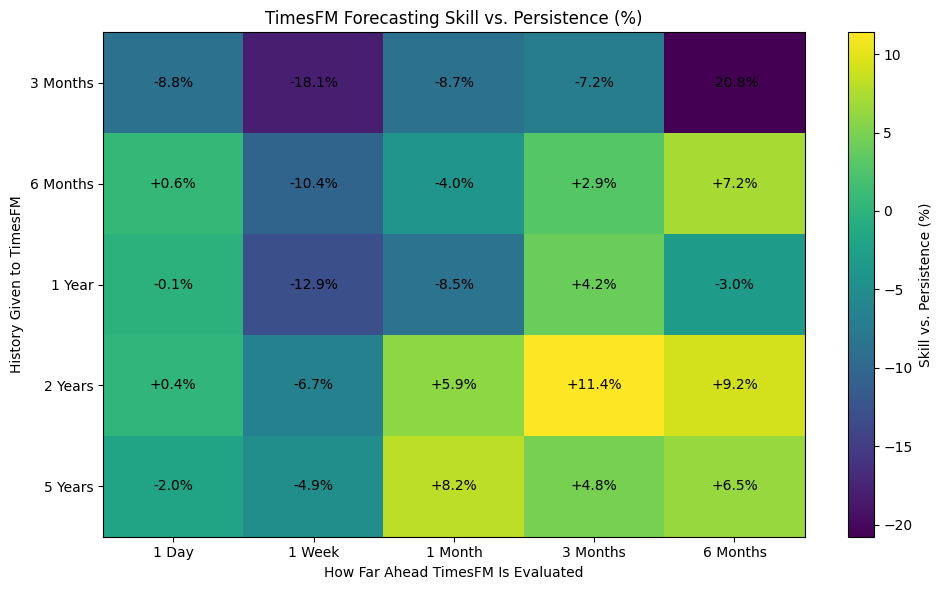

In [ ]:
# ============================================================
# HEATMAP: SKILL VS. PERSISTENCE
# ============================================================

lookback_order = [
    "3 Months",
    "6 Months",
    "1 Year",
    "2 Years",
    "5 Years"
]

horizon_order = [
    "1 Day",
    "1 Week",
    "1 Month",
    "3 Months",
    "6 Months"
]

skill_grid = (
    grid_summary
    .pivot(
        index="Lookback",
        columns="Horizon",
        values="Skill"
    )
    .reindex(
        index=lookback_order,
        columns=horizon_order
    )
    * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

image = ax.imshow(skill_grid.values, aspect="auto")

ax.set_xticks(range(len(horizon_order)))
ax.set_xticklabels(horizon_order)

ax.set_yticks(range(len(lookback_order)))
ax.set_yticklabels(lookback_order)

ax.set_xlabel("How Far Ahead TimesFM Is Evaluated")
ax.set_ylabel("History Given to TimesFM")
ax.set_title("TimesFM Forecasting Skill vs. Persistence (%)")

# Write the value inside every cell.
for i in range(skill_grid.shape[0]):
    for j in range(skill_grid.shape[1]):
        value = skill_grid.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:+.1f}%",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    ax=ax,
    label="Skill vs. Persistence (%)"
)

plt.tight_layout()
plt.show()

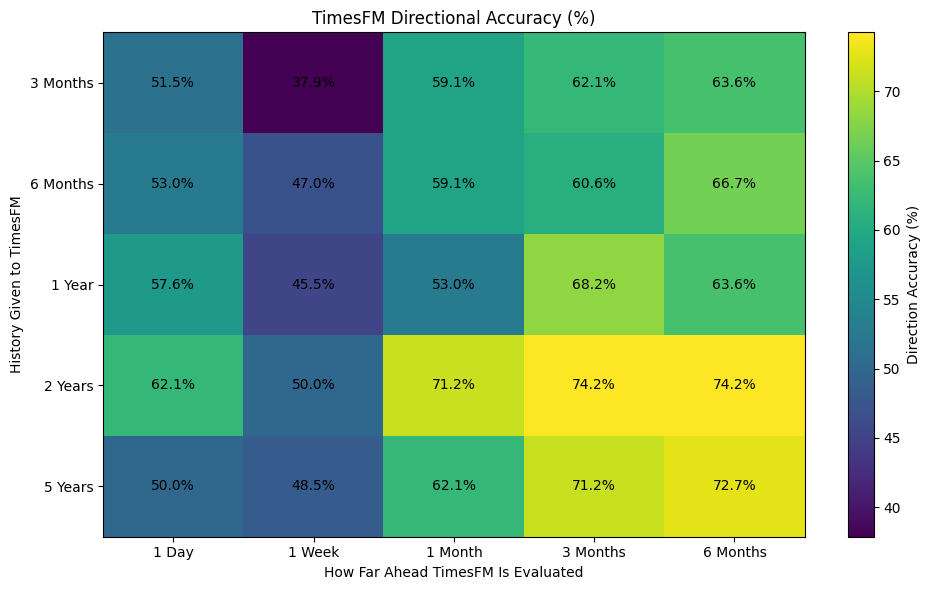

In [ ]:
# ============================================================
# HEATMAP: DIRECTIONAL ACCURACY
# ============================================================

direction_grid = (
    grid_summary
    .pivot(
        index="Lookback",
        columns="Horizon",
        values="Direction_Accuracy"
    )
    .reindex(
        index=lookback_order,
        columns=horizon_order
    )
    * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

image = ax.imshow(direction_grid.values, aspect="auto")

ax.set_xticks(range(len(horizon_order)))
ax.set_xticklabels(horizon_order)

ax.set_yticks(range(len(lookback_order)))
ax.set_yticklabels(lookback_order)

ax.set_xlabel("How Far Ahead TimesFM Is Evaluated")
ax.set_ylabel("History Given to TimesFM")
ax.set_title("TimesFM Directional Accuracy (%)")

for i in range(direction_grid.shape[0]):
    for j in range(direction_grid.shape[1]):
        value = direction_grid.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    ax=ax,
    label="Direction Accuracy (%)"
)

plt.tight_layout()
plt.show()

### How should we read these grids?

Each row represents a different amount of historical context given to TimesFM. Each column represents a different point in the future at which we evaluate the forecast. Moving from left to right therefore changes the **look-forward horizon**, while moving from top to bottom changes the **lookback window**.

The first heatmap measures **price forecasting skill relative to persistence**. A positive number means TimesFM predicted the future closing price more accurately than simply assuming the price would remain unchanged; a negative number means persistence did better.

The second heatmap measures something different: whether TimesFM correctly predicted if the future price would be above or below today's price. Those directional percentages are intuitive, but they need an additional benchmark. The S&P 500 tends to rise over long periods, so at a three- or six-month horizon, a model that simply predicts "up" every time may already achieve substantially more than 50% accuracy.

Before interpreting TimesFM's long-horizon directional results as genuine forecasting skill, we should therefore ask a simpler question: **how often would we have been right by always predicting that the S&P 500 would rise?**

In [ ]:
# ============================================================
# I. DIRECTIONAL BASELINE
# How well would "always predict up" have performed?
# ============================================================

# The same future outcome appears once for each lookback.
# For this baseline we only want to count each historical
# forecast episode once.

direction_events = (
    grid[
        [
            "Forecast Origin",
            "Horizon",
            "Days Ahead",
            "Actual Move"
        ]
    ]
    .drop_duplicates(
        subset=[
            "Forecast Origin",
            "Horizon",
            "Days Ahead"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# 1. HOW OFTEN DID SPY ACTUALLY GO UP?
# ------------------------------------------------------------

direction_baseline = (
    direction_events
    .groupby(["Horizon", "Days Ahead"])
    .agg(
        Forecasts=("Actual Move", "size"),
        Up_Rate=("Actual Move", lambda x: (x > 0).mean()),
        Down_Rate=("Actual Move", lambda x: (x < 0).mean())
    )
    .reset_index()
    .sort_values("Days Ahead")
)

# Accuracy of the simplest directional rule:
# always predict that SPY will be higher in the future.
direction_baseline["Always_Up_Accuracy"] = (
    direction_baseline["Up_Rate"]
)

baseline_display = direction_baseline.copy()

baseline_display["SPY Actually Rose %"] = (
    baseline_display["Up_Rate"] * 100
).round(1)

baseline_display["Always Predict Up Accuracy %"] = (
    baseline_display["Always_Up_Accuracy"] * 100
).round(1)

print("Directional baseline by forecast horizon:")

display(
    baseline_display[
        [
            "Horizon",
            "Forecasts",
            "SPY Actually Rose %",
            "Always Predict Up Accuracy %"
        ]
    ]
)


# ------------------------------------------------------------
# 2. COMPARE TIMESFM WITH THAT BASELINE
# ------------------------------------------------------------

direction_summary = grid_summary.merge(
    direction_baseline[
        [
            "Horizon",
            "Days Ahead",
            "Always_Up_Accuracy"
        ]
    ],
    on=["Horizon", "Days Ahead"],
    how="left"
)

direction_summary["Directional_Advantage"] = (
    direction_summary["Direction_Accuracy"]
    - direction_summary["Always_Up_Accuracy"]
)


# ------------------------------------------------------------
# 3. BUILD A HEATMAP OF DIRECTIONAL ADVANTAGE
#
# Positive = TimesFM beats always predicting "up"
# Negative = always predicting "up" does better
# ------------------------------------------------------------

lookback_order = [
    "3 Months",
    "6 Months",
    "1 Year",
    "2 Years",
    "5 Years"
]

horizon_order = [
    "1 Day",
    "1 Week",
    "1 Month",
    "3 Months",
    "6 Months"
]

direction_advantage_grid = (
    direction_summary
    .pivot(
        index="Lookback",
        columns="Horizon",
        values="Directional_Advantage"
    )
    .reindex(
        index=lookback_order,
        columns=horizon_order
    )
    * 100
)


fig, ax = plt.subplots(figsize=(10, 6))

image = ax.imshow(
    direction_advantage_grid.values,
    aspect="auto"
)

ax.set_xticks(range(len(horizon_order)))
ax.set_xticklabels(horizon_order)

ax.set_yticks(range(len(lookback_order)))
ax.set_yticklabels(lookback_order)

ax.set_xlabel("How Far Ahead TimesFM Is Evaluated")
ax.set_ylabel("History Given to TimesFM")

ax.set_title(
    "TimesFM Directional Advantage vs. Always Predicting Up"
)


# Write the percentage-point advantage inside every cell
for i in range(direction_advantage_grid.shape[0]):
    for j in range(direction_advantage_grid.shape[1]):

        value = direction_advantage_grid.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:+.1f} pp",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    ax=ax,
    label="Directional Advantage (percentage points)"
)

plt.tight_layout()
plt.show()

### What happened?

The three heatmaps tell a more nuanced story than directional accuracy alone suggested.

First, the amount of historical context clearly interacts with the forecast horizon. The shortest three-month context performs poorly almost everywhere: TimesFM loses to persistence at every horizon, including by 20.8% at six months. Longer histories generally work better, but there is no single lookback that dominates every column.

The strongest price-forecasting results appear with roughly two to five years of history. With a two-year lookback, TimesFM beats persistence by 5.9% at one month, 11.4% at three months, and 9.2% at six months. Five years also performs well at longer horizons, including an 8.2% improvement at one month. By contrast, the one-week horizon is unusually weak: every lookback performs worse than persistence. In this sample, TimesFM therefore appears more useful at medium and longer horizons than at roughly one trading week.

The directional results initially look even more impressive. With two years of history, TimesFM gets the direction right 71.2% of the time at one month and 74.2% of the time at both three and six months. But the third heatmap shows why absolute directional accuracy can be misleading for an asset such as the S&P 500. Over these same historical episodes, SPY rose 68.2% of the time over one month, 75.8% over three months, and 77.3% over six months. Simply predicting "up" every time would therefore already have achieved very high accuracy.

Once we compare TimesFM with that stronger directional baseline, most of the apparent long-horizon advantage disappears. The two-year lookback still beats "always up" by 3.0 percentage points at one month, but trails it slightly at three months and by 3.0 points at six months. Its clearest directional advantage remains at the one-day horizon, where it beats the natural upward base rate by 6.1 percentage points.

This distinction is important. TimesFM can improve the accuracy of its **price estimate** even when it does not improve the binary question of whether the market will be higher or lower. At three months, for example, the two-year model reduces price error by 11.4% relative to persistence even though "always predict up" is slightly better at predicting direction. The model may therefore contain useful information about **how far the market is likely to move**, rather than simply whether it will rise.

These results are still based on only 66 common historical forecast origins, so they should be treated as exploratory. But a pattern is beginning to emerge: very short context looks consistently weak, roughly two years of history looks especially promising, the one-week horizon appears difficult, and TimesFM's strongest medium-term evidence comes from improving the predicted price level rather than merely exploiting the S&P 500's tendency to rise.

## J. Does TimesFM's forecasting skill generalize across markets?

Everything so far has been learned from a single asset: the S&P 500. That makes SPY a useful laboratory, but not yet evidence that TimesFM has broadly useful financial forecasting ability. A pattern that appears in one major U.S. equity index could reflect something peculiar about that market rather than something general about the model.

We therefore now move from one asset to a deliberately heterogeneous universe of **50 financial assets**. The sample spans U.S. and international equities, government bonds and corporate credit, commodities, currencies, and cryptocurrencies. The objective is not yet to identify the particular kinds of assets on which TimesFM works best. It is to ask a more basic question first: **does the forecasting advantage we observed in SPY survive when the model is exposed to fundamentally different markets?**

We will freeze the forecasting experiment rather than redesign it for each asset. Every market will be tested using the same five lookback windows and the same five look-forward horizons. Our two principal outcomes remain the ones developed in the SPY experiments: **forecasting skill relative to persistence** and **directional accuracy**, interpreted relative to each asset's own tendency to rise or fall.

Because the assets trade at radically different price levels, raw forecast errors cannot be compared directly across the universe. A ten-dollar error means something very different for a currency, a stock index, and Bitcoin. Skill relative to persistence solves much of this problem by asking a standardized question within each asset: **how much does TimesFM reduce forecasting error compared with simply assuming that the current price will persist?**

This is intentionally a broad replication experiment. Only after seeing whether TimesFM's performance generalizes across the full universe will we ask why performance differs — for example, whether it is systematically related to volatility, asset class, forecast horizon, or other market characteristics.

In [ ]:
# ============================================================
# J. BUILD A MAXIMALLY DIVERSE 50-ASSET UNIVERSE
# ============================================================

asset_universe = {

    # --------------------------------------------------------
    # U.S. EQUITIES
    # Broad market, size, style, and sector exposures
    # --------------------------------------------------------
    "SPY":     ("S&P 500", "U.S. Equity"),
    "QQQ":     ("Nasdaq 100", "U.S. Equity"),
    "IWM":     ("Russell 2000", "U.S. Equity"),
    "DIA":     ("Dow Jones Industrial Average", "U.S. Equity"),
    "VTV":     ("U.S. Value Stocks", "U.S. Equity"),
    "VUG":     ("U.S. Growth Stocks", "U.S. Equity"),
    "XLE":     ("U.S. Energy Stocks", "U.S. Equity"),
    "XLV":     ("U.S. Health Care Stocks", "U.S. Equity"),
    "XLP":     ("U.S. Consumer Staples Stocks", "U.S. Equity"),
    "VNQ":     ("U.S. Real Estate", "Real Estate"),

    # --------------------------------------------------------
    # INTERNATIONAL EQUITIES
    # Developed, emerging, and major regional markets
    # --------------------------------------------------------
    "EFA":     ("Developed Markets ex-U.S.", "International Equity"),
    "EEM":     ("Emerging Markets", "International Equity"),
    "EWJ":     ("Japan", "International Equity"),
    "EWZ":     ("Brazil", "International Equity"),
    "FXI":     ("China Large-Cap", "International Equity"),
    "INDA":    ("India", "International Equity"),
    "EWU":     ("United Kingdom", "International Equity"),
    "EWG":     ("Germany", "International Equity"),

    # --------------------------------------------------------
    # FIXED INCOME
    # Cash-like debt through long duration and risky credit
    # --------------------------------------------------------
    "BIL":     ("U.S. Treasury Bills", "Fixed Income"),
    "SHY":     ("1–3 Year U.S. Treasuries", "Fixed Income"),
    "IEF":     ("7–10 Year U.S. Treasuries", "Fixed Income"),
    "TLT":     ("20+ Year U.S. Treasuries", "Fixed Income"),
    "TIP":     ("Inflation-Protected Treasuries", "Fixed Income"),
    "BND":     ("U.S. Aggregate Bonds", "Fixed Income"),
    "LQD":     ("Investment-Grade Corporate Bonds", "Fixed Income"),
    "VCIT":    ("Intermediate Corporate Bonds", "Fixed Income"),
    "HYG":     ("High-Yield Corporate Bonds", "Fixed Income"),
    "EMB":     ("Emerging-Market Sovereign Debt", "Fixed Income"),

    # --------------------------------------------------------
    # COMMODITIES
    # Precious metals, energy, industrial metals, agriculture
    # --------------------------------------------------------
    "GLD":     ("Gold", "Commodity"),
    "SLV":     ("Silver", "Commodity"),
    "USO":     ("Crude Oil", "Commodity"),
    "UNG":     ("Natural Gas", "Commodity"),
    "DBC":     ("Broad Commodities", "Commodity"),
    "DBA":     ("Agricultural Commodities", "Commodity"),
    "CPER":    ("Copper", "Commodity"),
    "CORN":    ("Corn", "Commodity"),
    "WEAT":    ("Wheat", "Commodity"),
    "SOYB":    ("Soybeans", "Commodity"),

    # --------------------------------------------------------
    # FOREIGN EXCHANGE
    # Major developed-market currency relationships
    # --------------------------------------------------------
    "EURUSD=X": ("Euro / U.S. Dollar", "FX"),
    "GBPUSD=X": ("British Pound / U.S. Dollar", "FX"),
    "JPY=X":    ("U.S. Dollar / Japanese Yen", "FX"),
    "AUDUSD=X": ("Australian Dollar / U.S. Dollar", "FX"),
    "NZDUSD=X": ("New Zealand Dollar / U.S. Dollar", "FX"),
    "CAD=X":    ("U.S. Dollar / Canadian Dollar", "FX"),
    "CHF=X":    ("U.S. Dollar / Swiss Franc", "FX"),
    "EURJPY=X": ("Euro / Japanese Yen", "FX"),

    # --------------------------------------------------------
    # CRYPTO
    # Large, long-lived digital assets
    # --------------------------------------------------------
    "BTC-USD": ("Bitcoin", "Crypto"),
    "ETH-USD": ("Ethereum", "Crypto"),
    "LTC-USD": ("Litecoin", "Crypto"),
    "XRP-USD": ("XRP", "Crypto"),
}

print("Assets:", len(asset_universe))


# ============================================================
# DOWNLOAD THE FULL UNIVERSE
#
# auto_adjust=True means equity and ETF price histories are
# adjusted for stock splits and distributions. For FX and
# crypto, the Close series remains the relevant market price.
# ============================================================

raw_assets = yf.download(
    list(asset_universe.keys()),
    start="2010-01-01",
    auto_adjust=True,
    progress=False
)

asset_prices = raw_assets["Close"].copy()

# Preserve our intended column ordering
asset_prices = asset_prices[
    list(asset_universe.keys())
]


print(
    "\nRaw date range:",
    asset_prices.index.min().date(),
    "to",
    asset_prices.index.max().date()
)

print("Raw rows:", len(asset_prices))


# ============================================================
# BUILD METADATA + COVERAGE TABLE
# ============================================================

asset_metadata = pd.DataFrame(
    [
        {
            "Ticker": ticker,
            "Asset": name,
            "Asset Class": asset_class
        }
        for ticker, (name, asset_class)
        in asset_universe.items()
    ]
).set_index("Ticker")


asset_coverage = asset_metadata.copy()

asset_coverage["First Date"] = asset_prices.apply(
    lambda x: x.first_valid_index()
)

asset_coverage["Last Date"] = asset_prices.apply(
    lambda x: x.last_valid_index()
)

asset_coverage["Observations"] = asset_prices.count()

asset_coverage["Missing"] = asset_prices.isna().sum()


print("\nAssets by class:")
display(
    asset_metadata["Asset Class"]
    .value_counts()
    .rename("Assets")
    .to_frame()
)

print("\nCoverage:")
display(asset_coverage)

Assets: 50

Raw date range: 2010-01-01 to 2026-09-04
Raw rows: 5599

Assets by class:


,Assets
Asset Class,
Fixed Income,10
Commodity,10
U.S. Equity,9
FX,8
International Equity,8
Crypto,4
Real Estate,1



Coverage:


,Asset,Asset Class,First Date,Last Date,Observations,Missing
Ticker,,,,,,
SPY,S&P 500,U.S. Equity,2010-01-04,2026-09-04,4194,1405
QQQ,Nasdaq 100,U.S. Equity,2010-01-04,2026-09-04,4194,1405
IWM,Russell 2000,U.S. Equity,2010-01-04,2026-09-04,4194,1405
DIA,Dow Jones Industrial Average,U.S. Equity,2010-01-04,2026-09-04,4194,1405
VTV,U.S. Value Stocks,U.S. Equity,2010-01-04,2026-09-04,4194,1405
VUG,U.S. Growth Stocks,U.S. Equity,2010-01-04,2026-09-04,4194,1405
XLE,U.S. Energy Stocks,U.S. Equity,2010-01-04,2026-09-04,4194,1405
XLV,U.S. Health Care Stocks,U.S. Equity,2010-01-04,2026-09-04,4194,1405
XLP,U.S. Consumer Staples Stocks,U.S. Equity,2010-01-04,2026-09-04,4194,1405


### Putting 50 very different markets on the same clock

A cross-market experiment introduces a complication that did not matter when we studied SPY alone. Different markets observe different calendars. U.S. ETFs trade on business days, foreign exchange trades through most of the week, and cryptocurrencies trade seven days a week. If we simply counted observations, a 20-step Bitcoin forecast would cover a shorter calendar period than a 20-step stock forecast.

For the main replication, we therefore place every asset on the same **U.S. trading-day calendar**, using the dates on which SPY trades. This deliberately discards weekend crypto observations, but it ensures that our lookback and look-forward windows have the same meaning across the entire universe.

We will also use a balanced historical sample. Rather than allowing newer assets to enter only some parts of the experiment, we will find the earliest historical point at which all 50 assets have enough data for our longest five-year lookback, and we will stop early enough to observe the full six-month future. Every cell in the resulting comparison can then refer to the same assets and the same historical forecast dates.

In [ ]:
# ============================================================
# J. BUILD A COMPLETE COMMON MARKET CALENDAR
# ============================================================

# We already aligned everything to SPY trading dates.
# Now remove the relatively small number of dates on which
# ANY of the 50 assets lacks an observation.

balanced_prices = aligned_prices.dropna(axis=0, how="any").copy()

print("SPY-calendar rows before complete-case filtering:",
      len(aligned_prices))

print("Common complete-market rows:",
      len(balanced_prices))

print(
    "Common calendar:",
    balanced_prices.index.min().date(),
    "to",
    balanced_prices.index.max().date()
)

print(
    "Remaining missing values:",
    int(balanced_prices.isna().sum().sum())
)


# ------------------------------------------------------------
# Every remaining row is now a date observed for all 50 assets.
# We can therefore define common historical forecast origins
# simply by position in this shared series.
# ------------------------------------------------------------

eligible_positions = list(
    range(
        max_lookback,
        len(balanced_prices) - max_horizon + 1
    )
)

# Roughly monthly historical sampling,
# matching the exploratory SPY experiment.
common_origin_positions = eligible_positions[::20]

print("\nEligible daily origins:", len(eligible_positions))
print("Sampled historical origins:", len(common_origin_positions))

if common_origin_positions:

    first_pos = common_origin_positions[0]
    last_pos = common_origin_positions[-1]

    print(
        "\nFirst forecast origin:",
        balanced_prices.index[first_pos - 1].date()
    )

    print(
        "Last forecast origin:",
        balanced_prices.index[last_pos - 1].date()
    )

    print(
        "Last observable 6-month target:",
        balanced_prices.index[
            last_pos + max_horizon - 1
        ].date()
    )

SPY-calendar rows before complete-case filtering: 4194
Common complete-market rows: 2213
Common calendar: 2017-11-09 to 2026-09-04
Remaining missing values: 0

Eligible daily origins: 834
Sampled historical origins: 42

First forecast origin: 2022-11-14
Last forecast origin: 2026-02-25
Last observable 6-month target: 2026-08-18


### A balanced test across 50 markets

Moving from SPY to 50 very different markets introduces a problem we did not have before: they do not all observe the same calendar. U.S. securities trade on business days, currencies follow a somewhat different weekly schedule, and cryptocurrencies trade continuously. We therefore placed every series onto the SPY trading calendar and then retained only dates on which all 50 assets have an observed price. No missing prices are filled or invented.

This leaves a common market history beginning in November 2017. Once we also require enough past data for our longest five-year lookback and enough future data to evaluate a six-month forecast, we are left with **42 common historical forecast dates**, running from late 2022 through early 2026.

That is a smaller historical sample than we had for SPY alone, but it buys us a much cleaner comparison. Every result below will be based on the **same 50 assets and the same 42 historical episodes**. Differences across lookbacks and forecast horizons therefore cannot be explained by changing which assets or dates happen to be included.

We now freeze the experiment developed on SPY and replicate it without changing the rules. For every historical date, each asset will be shown one of five amounts of prior history — approximately three months, six months, one year, two years, or five years. TimesFM will then generate a six-month forecast path, which we will evaluate after one day, one week, one month, three months, and six months.

The full experiment produces **52,500 scored forecasts**: 50 assets × 42 historical dates × 5 lookbacks × 5 evaluation horizons. Because TimesFM can forecast multiple independent series in a batch, this requires only **210 model calls**. At this stage we are not yet looking for winning asset classes or explaining why some markets may be easier to forecast. The first question is simpler: **does the forecasting behavior we saw in SPY replicate across a broad and economically diverse collection of markets?**

In [ ]:
# ============================================================
# J. RUN THE FULL 50-ASSET REPLICATION
# ============================================================

import time

tickers = list(asset_universe.keys())

replication_rows = []

total_batches = (
    len(lookbacks) *
    len(common_origin_positions)
)

expected_rows = (
    len(tickers) *
    len(common_origin_positions) *
    len(lookbacks) *
    len(forward_horizons)
)

print("FULL REPLICATION")
print("----------------")
print(f"Assets:              {len(tickers)}")
print(f"Historical origins:  {len(common_origin_positions)}")
print(f"Lookbacks:           {len(lookbacks)}")
print(f"Forecast horizons:   {len(forward_horizons)}")
print(f"TimesFM batch calls: {total_batches}")
print(f"Expected scored rows:{expected_rows:,}")
print("\nRunning on CPU — this may take a while.\n")


# One progress bar for the entire experiment
progress = tqdm(
    total=total_batches,
    desc="50-asset replication"
)

start_time = time.time()


for lookback_name, lookback_days in lookbacks.items():

    for pos in common_origin_positions:

        forecast_origin = balanced_prices.index[pos - 1]


        # ----------------------------------------------------
        # BUILD 50 HISTORICAL CONTEXTS
        # ----------------------------------------------------

        contexts = []

        for ticker in tickers:

            context_i = (
                balanced_prices[ticker]
                .iloc[pos - lookback_days:pos]
                .to_numpy(dtype=np.float32)
            )

            contexts.append(context_i)


        # ----------------------------------------------------
        # FORECAST ALL 50 ASSETS TOGETHER
        #
        # One call produces a 120-step forecast for every asset.
        # ----------------------------------------------------

        outputs = list(
            forecaster.predict_batch(
                contexts=contexts,
                horizon=max_horizon,
                ts_ids=tickers
            )
        )


        # Sanity check
        if len(outputs) != len(tickers):

            raise RuntimeError(
                f"Expected {len(tickers)} outputs, "
                f"but TimesFM returned {len(outputs)}."
            )


        # ----------------------------------------------------
        # SCORE EACH ASSET AT 1 / 5 / 20 / 60 / 120 STEPS
        # ----------------------------------------------------

        for ticker, context_i, output_i in zip(
            tickers,
            contexts,
            outputs
        ):

            asset_name, asset_class = asset_universe[ticker]

            forecast_path = np.asarray(
                output_i.forecast
            ).squeeze()

            last_known_price = float(
                context_i[-1]
            )


            for horizon_name, h in forward_horizons.items():

                predicted_price = float(
                    forecast_path[h - 1]
                )

                actual_price = float(
                    balanced_prices[ticker]
                    .iloc[pos + h - 1]
                )

                target_date = (
                    balanced_prices.index[
                        pos + h - 1
                    ]
                )


                replication_rows.append({

                    "Ticker": ticker,
                    "Asset": asset_name,
                    "Asset Class": asset_class,

                    "Forecast Origin": forecast_origin,
                    "Target Date": target_date,

                    "Lookback": lookback_name,
                    "Lookback Days": lookback_days,

                    "Horizon": horizon_name,
                    "Days Ahead": h,

                    "Last Known Price": last_known_price,
                    "TimesFM Forecast": predicted_price,
                    "Actual Price": actual_price
                })


        progress.update(1)


progress.close()


# ============================================================
# COMBINE EVERYTHING INTO ONE TABLE
# ============================================================

replication_results = pd.DataFrame(
    replication_rows
)

elapsed = time.time() - start_time


print("\n✓ REPLICATION COMPLETE")
print("----------------------")

print(
    f"Runtime: "
    f"{elapsed / 60:.1f} minutes"
)

print(
    f"Rows: "
    f"{len(replication_results):,} "
    f"(expected {expected_rows:,})"
)

print(
    "Assets:",
    replication_results["Ticker"].nunique()
)

print(
    "Forecast origins:",
    replication_results[
        "Forecast Origin"
    ].nunique()
)

print(
    "Lookbacks:",
    replication_results[
        "Lookback"
    ].nunique()
)

print(
    "Horizons:",
    replication_results[
        "Horizon"
    ].nunique()
)


# Final integrity check
assert len(replication_results) == expected_rows

assert (
    replication_results[
        "Ticker"
    ].nunique()
    == len(tickers)
)


display(
    replication_results.head(10)
)

FULL REPLICATION
----------------
Assets:              50
Historical origins:  42
Lookbacks:           5
Forecast horizons:   5
TimesFM batch calls: 210
Expected scored rows:52,500

Running on CPU — this may take a while.



50-asset replication:   0%|          | 0/210 [00:00<?, ?it/s]


✓ REPLICATION COMPLETE
----------------------
Runtime: 55.2 minutes
Rows: 52,500 (expected 52,500)
Assets: 50
Forecast origins: 42
Lookbacks: 5
Horizons: 5


,Ticker,Asset,Asset Class,Forecast Origin,Target Date,Lookback,Lookback Days,Horizon,Days Ahead,Last Known Price,TimesFM Forecast,Actual Price
0,SPY,S&P 500,U.S. Equity,2022-11-14,2022-11-15,3 Months,63,1 Day,1,376.080383,374.410919,379.288025
1,SPY,S&P 500,U.S. Equity,2022-11-14,2022-11-21,3 Months,63,1 Week,5,376.080383,371.201996,375.575958
2,SPY,S&P 500,U.S. Equity,2022-11-14,2022-12-13,3 Months,63,1 Month,20,376.080383,362.136230,382.600372
3,SPY,S&P 500,U.S. Equity,2022-11-14,2023-02-10,3 Months,63,3 Months,60,376.080383,365.718231,390.161316
4,SPY,S&P 500,U.S. Equity,2022-11-14,2023-05-09,3 Months,63,6 Months,120,376.080383,357.939575,394.424286
5,QQQ,Nasdaq 100,U.S. Equity,2022-11-14,2022-11-15,3 Months,63,1 Day,1,279.056152,276.733276,282.917786
6,QQQ,Nasdaq 100,U.S. Equity,2022-11-14,2022-11-21,3 Months,63,1 Week,5,279.056152,273.699249,275.585510
7,QQQ,Nasdaq 100,U.S. Equity,2022-11-14,2022-12-13,3 Months,63,1 Month,20,279.056152,270.096375,282.194305
8,QQQ,Nasdaq 100,U.S. Equity,2022-11-14,2023-02-10,3 Months,63,3 Months,60,279.056152,271.287628,293.698669
9,QQQ,Nasdaq 100,U.S. Equity,2022-11-14,2023-05-09,3 Months,63,6 Months,120,279.056152,267.326752,315.687256


### Did the SPY result generalize?

The replication is complete: 50 assets, 42 common historical forecast dates, five lookbacks, and five forecast horizons produced 52,500 scored predictions.

The next step is deliberately aggregate. Before asking whether TimesFM works especially well on crypto, volatile markets, bonds, or any other subgroup, we want to know whether it shows forecasting skill across the universe as a whole.

Because these markets trade at radically different price levels, we cannot sensibly average their raw errors together. Instead, we first evaluate TimesFM separately within each asset. For every asset, lookback, and forecast horizon, we calculate how much TimesFM reduces mean absolute error relative to persistence. We then summarize those asset-level skill scores across the 50 markets.

We will look at three complementary views. **Median forecasting skill** tells us the performance of the typical asset. **The percentage of assets with positive skill** tells us how broadly any advantage is distributed rather than allowing a few unusually successful markets to dominate the average. Finally, we will measure **directional advantage relative to each asset's own directional base rate**, asking whether TimesFM is better at predicting up versus down than a naive rule tailored to that market's historical tendency.

In [ ]:
# ============================================================
# J. SCORE THE 50-ASSET REPLICATION
# ============================================================

r = replication_results.copy()


# ------------------------------------------------------------
# 1. FORECAST ERRORS
# ------------------------------------------------------------

r["TimesFM Error"] = (
    r["TimesFM Forecast"] -
    r["Actual Price"]
).abs()

r["Persistence Error"] = (
    r["Last Known Price"] -
    r["Actual Price"]
).abs()


# ------------------------------------------------------------
# 2. DIRECTIONAL OUTCOMES
# ------------------------------------------------------------

r["Predicted Move"] = (
    r["TimesFM Forecast"] /
    r["Last Known Price"] - 1
)

r["Actual Move"] = (
    r["Actual Price"] /
    r["Last Known Price"] - 1
)

r["Direction Correct"] = (
    np.sign(r["Predicted Move"]) ==
    np.sign(r["Actual Move"])
)


# ------------------------------------------------------------
# 3. SCORE EACH ASSET SEPARATELY
#
# This is important: we do NOT pool raw errors across assets.
# Bitcoin, EUR/USD, bonds, etc. have incomparable price scales.
# ------------------------------------------------------------

asset_scores = (
    r.groupby([
        "Ticker",
        "Asset",
        "Asset Class",
        "Lookback",
        "Lookback Days",
        "Horizon",
        "Days Ahead"
    ])
    .agg(
        Forecasts=("Actual Price", "size"),
        TimesFM_MAE=("TimesFM Error", "mean"),
        Persistence_MAE=("Persistence Error", "mean"),
        Direction_Accuracy=("Direction Correct", "mean")
    )
    .reset_index()
)


# Forecasting skill relative to persistence
asset_scores["Skill"] = (
    1 -
    asset_scores["TimesFM_MAE"] /
    asset_scores["Persistence_MAE"]
)


# ------------------------------------------------------------
# 4. DIRECTIONAL BASELINE FOR EACH ASSET
#
# How often did this particular asset actually rise at each
# horizon over the 42 common historical episodes?
#
# The future outcome is repeated across lookbacks, so first
# deduplicate to one observation per asset/origin/horizon.
# ------------------------------------------------------------

direction_events = (
    r[[
        "Ticker",
        "Forecast Origin",
        "Horizon",
        "Days Ahead",
        "Actual Move"
    ]]
    .drop_duplicates(
        subset=[
            "Ticker",
            "Forecast Origin",
            "Horizon"
        ]
    )
)

asset_direction_baseline = (
    direction_events
    .groupby([
        "Ticker",
        "Horizon",
        "Days Ahead"
    ])
    .agg(
        Up_Rate=("Actual Move", lambda x: (x > 0).mean()),
        Down_Rate=("Actual Move", lambda x: (x < 0).mean())
    )
    .reset_index()
)


# A naive directional forecaster should predict whichever
# direction happened more often for that asset and horizon.
#
# This is stronger and fairer than simply using 50%.
asset_direction_baseline["Naive_Direction_Accuracy"] = (
    asset_direction_baseline[
        ["Up_Rate", "Down_Rate"]
    ].max(axis=1)
)


asset_scores = asset_scores.merge(
    asset_direction_baseline[[
        "Ticker",
        "Horizon",
        "Days Ahead",
        "Naive_Direction_Accuracy"
    ]],
    on=[
        "Ticker",
        "Horizon",
        "Days Ahead"
    ],
    how="left"
)


asset_scores["Directional_Advantage"] = (
    asset_scores["Direction_Accuracy"] -
    asset_scores["Naive_Direction_Accuracy"]
)


# ------------------------------------------------------------
# 5. AGGREGATE ACROSS THE 50 ASSETS
#
# Every asset receives equal weight.
# ------------------------------------------------------------

replication_summary = (
    asset_scores
    .groupby([
        "Lookback",
        "Lookback Days",
        "Horizon",
        "Days Ahead"
    ])
    .agg(
        Assets=("Ticker", "nunique"),

        Median_Skill=("Skill", "median"),
        Mean_Skill=("Skill", "mean"),

        Assets_Positive_Skill=(
            "Skill",
            lambda x: (x > 0).mean()
        ),

        Median_Direction_Accuracy=(
            "Direction_Accuracy",
            "median"
        ),

        Median_Naive_Direction_Accuracy=(
            "Naive_Direction_Accuracy",
            "median"
        ),

        Median_Directional_Advantage=(
            "Directional_Advantage",
            "median"
        ),

        Assets_Positive_Directional_Advantage=(
            "Directional_Advantage",
            lambda x: (x > 0).mean()
        )
    )
    .reset_index()
)


print("Asset-level score rows:", len(asset_scores))
print("Aggregate grid cells:", len(replication_summary))

display(
    replication_summary.head(10)
)

Asset-level score rows: 1250
Aggregate grid cells: 25


,Lookback,Lookback Days,Horizon,Days Ahead,Assets,Median_Skill,Mean_Skill,Assets_Positive_Skill,Median_Direction_Accuracy,Median_Naive_Direction_Accuracy,Median_Directional_Advantage,Assets_Positive_Directional_Advantage
0,1 Year,252,1 Day,1,50,-0.023364,-0.020882,0.26,0.500000,0.547619,-0.071429,0.24
1,1 Year,252,1 Month,20,50,-0.061211,-0.035881,0.28,0.500000,0.595238,-0.071429,0.14
2,1 Year,252,1 Week,5,50,-0.035249,-0.017696,0.30,0.511905,0.547619,-0.047619,0.12
3,1 Year,252,3 Months,60,50,-0.059737,-0.049575,0.34,0.547619,0.654762,-0.119048,0.14
4,1 Year,252,6 Months,120,50,-0.039843,-0.062128,0.44,0.595238,0.702381,-0.166667,0.16
5,2 Years,504,1 Day,1,50,-0.009082,-0.002067,0.38,0.535714,0.547619,-0.023810,0.44
6,2 Years,504,1 Month,20,50,-0.026223,0.002545,0.40,0.523810,0.595238,-0.071429,0.14
7,2 Years,504,1 Week,5,50,-0.020731,0.003475,0.34,0.500000,0.547619,-0.071429,0.22
8,2 Years,504,3 Months,60,50,-0.024725,-0.010449,0.38,0.523810,0.654762,-0.095238,0.10
9,2 Years,504,6 Months,120,50,-0.047500,-0.005607,0.40,0.547619,0.702381,-0.154762,0.10


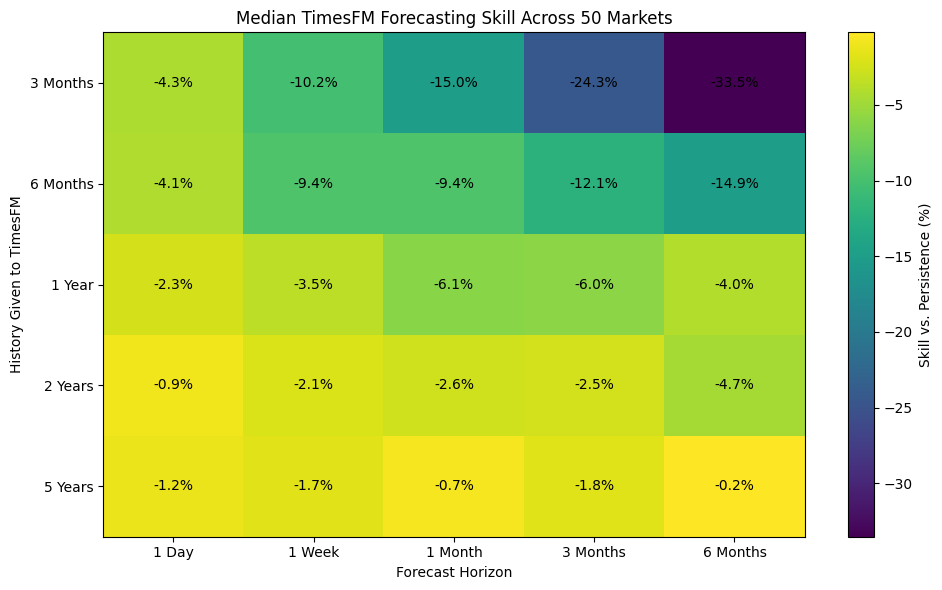

In [ ]:
# ============================================================
# HEATMAP 1: MEDIAN FORECASTING SKILL ACROSS 50 ASSETS
# ============================================================

median_skill_grid = (
    replication_summary
    .pivot(
        index="Lookback",
        columns="Horizon",
        values="Median_Skill"
    )
    .reindex(
        index=lookback_order,
        columns=horizon_order
    )
    * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

image = ax.imshow(
    median_skill_grid.values,
    aspect="auto"
)

ax.set_xticks(range(len(horizon_order)))
ax.set_xticklabels(horizon_order)

ax.set_yticks(range(len(lookback_order)))
ax.set_yticklabels(lookback_order)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("History Given to TimesFM")

ax.set_title(
    "Median TimesFM Forecasting Skill Across 50 Markets"
)

for i in range(median_skill_grid.shape[0]):
    for j in range(median_skill_grid.shape[1]):

        value = median_skill_grid.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:+.1f}%",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    ax=ax,
    label="Skill vs. Persistence (%)"
)

plt.tight_layout()
plt.show()

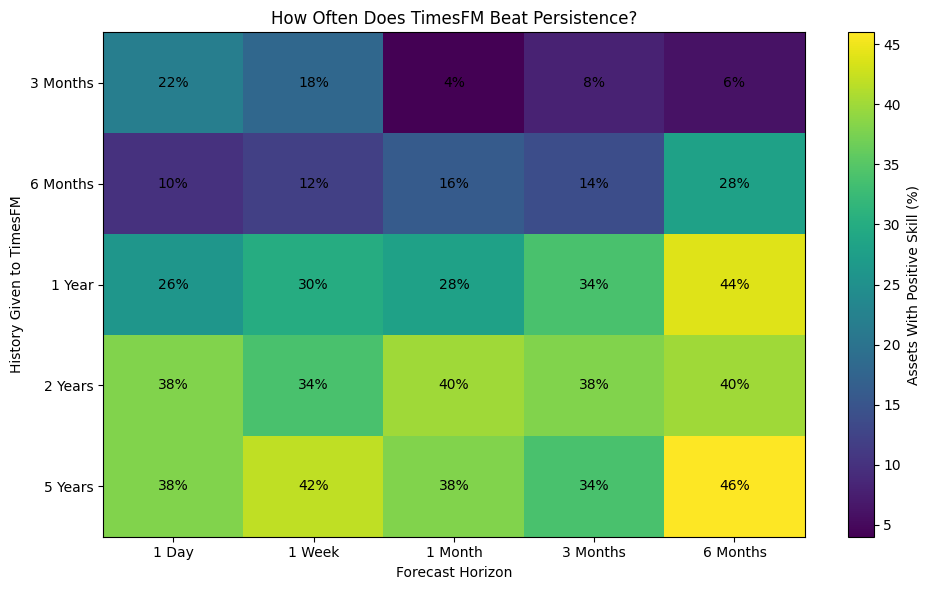

In [ ]:
# ============================================================
# HEATMAP 2: PERCENTAGE OF ASSETS BEATING PERSISTENCE
# ============================================================

positive_skill_grid = (
    replication_summary
    .pivot(
        index="Lookback",
        columns="Horizon",
        values="Assets_Positive_Skill"
    )
    .reindex(
        index=lookback_order,
        columns=horizon_order
    )
    * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

image = ax.imshow(
    positive_skill_grid.values,
    aspect="auto"
)

ax.set_xticks(range(len(horizon_order)))
ax.set_xticklabels(horizon_order)

ax.set_yticks(range(len(lookback_order)))
ax.set_yticklabels(lookback_order)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("History Given to TimesFM")

ax.set_title(
    "How Often Does TimesFM Beat Persistence?"
)

for i in range(positive_skill_grid.shape[0]):
    for j in range(positive_skill_grid.shape[1]):

        value = positive_skill_grid.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.0f}%",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    ax=ax,
    label="Assets With Positive Skill (%)"
)

plt.tight_layout()
plt.show()

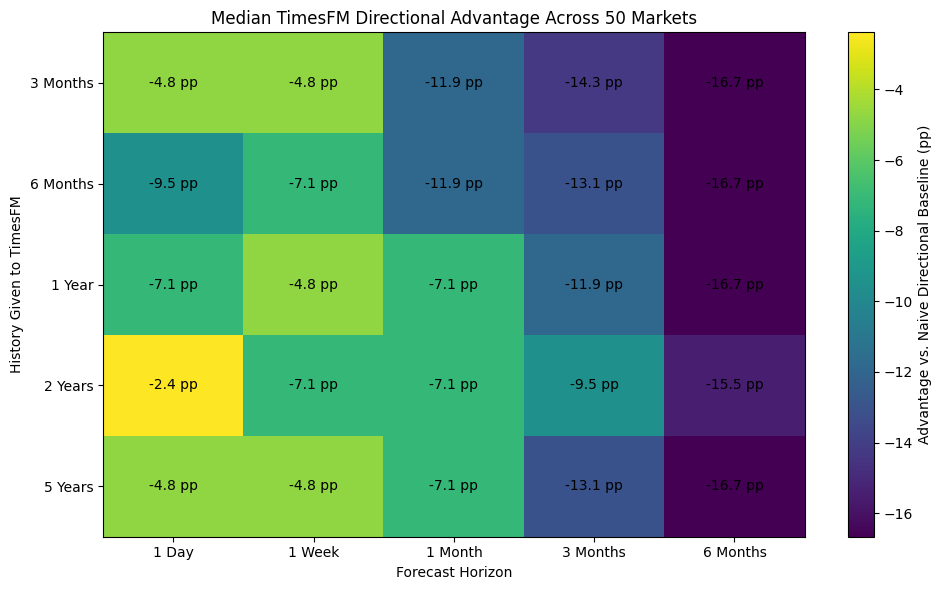

In [ ]:
# ============================================================
# HEATMAP 3: MEDIAN DIRECTIONAL ADVANTAGE
# ============================================================

direction_advantage_grid = (
    replication_summary
    .pivot(
        index="Lookback",
        columns="Horizon",
        values="Median_Directional_Advantage"
    )
    .reindex(
        index=lookback_order,
        columns=horizon_order
    )
    * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

image = ax.imshow(
    direction_advantage_grid.values,
    aspect="auto"
)

ax.set_xticks(range(len(horizon_order)))
ax.set_xticklabels(horizon_order)

ax.set_yticks(range(len(lookback_order)))
ax.set_yticklabels(lookback_order)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("History Given to TimesFM")

ax.set_title(
    "Median TimesFM Directional Advantage Across 50 Markets"
)

for i in range(direction_advantage_grid.shape[0]):
    for j in range(direction_advantage_grid.shape[1]):

        value = direction_advantage_grid.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:+.1f} pp",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    ax=ax,
    label="Advantage vs. Naive Directional Baseline (pp)"
)

plt.tight_layout()
plt.show()

### What happened?

The broad replication is much less favorable to TimesFM than the original S&P 500 experiment.

Across the 50-market universe, **median forecasting skill is negative in every combination of lookback and forecast horizon**. In other words, for the typical asset, TimesFM's predicted price is less accurate than the simple persistence forecast that assumes the future price will equal today's price.

The amount of historical context still matters substantially. Short contexts perform especially poorly. With only three months of history, median skill deteriorates from -4.3% at one day to -33.5% at six months. As the lookback grows, the gap narrows dramatically. Five years of history produces results close to persistence across most horizons and comes within just 0.2% of it at six months. The pattern we saw in SPY — that very short context appears unhelpful — therefore generalizes much more convincingly than SPY's apparent positive forecasting skill.

The second heatmap reveals an important qualification. Negative median performance does not mean TimesFM fails on every market. With longer histories, a substantial minority of assets beat persistence. At the five-year lookback, TimesFM has positive forecasting skill on 38% of assets at one day, 42% at one week, and 46% at six months. The broad average result is therefore negative, but there is considerable heterogeneity underneath it.

Directional forecasting is less encouraging. After comparing TimesFM with a naive rule that simply predicts each asset's historically more common direction, median directional advantage is negative in every cell. The disadvantage becomes particularly large at longer forecast horizons. High raw directional accuracy can therefore be misleading: much of it can be reproduced — and often exceeded — by knowing only an asset's directional base rate.

Taken together, the replication changes the question. We do not have evidence that TimesFM is a generally superior financial forecaster across markets. But neither is the result simply universal failure. Performance varies substantially across assets, and longer historical contexts appear consistently less damaging than shorter ones. The next question is therefore no longer simply **"Does TimesFM work?"** It is **"What characteristics distinguish the markets in which TimesFM adds forecasting value from those in which it does not?"**

## K. Why does TimesFM work better on some markets than others?

The broad replication showed that TimesFM does not beat persistence for the typical asset, but it also revealed substantial heterogeneity: some markets perform considerably better than others. We can now begin asking whether that variation has structure.

For this first exploratory analysis, we will focus on a single outcome: **forecasting skill relative to persistence**. Rather than selecting whichever lookback and horizon happened to produce the strongest result, we will summarize each asset by its **median skill across all 25 lookback × forecast-horizon combinations**. Every asset therefore contributes one number describing how well TimesFM performed across the experiment as a whole.

We will test two hypotheses that were motivated before inspecting the individual winners. First, performance may differ systematically across **asset classes**. Equities, bonds, currencies, commodities, and cryptocurrencies represent very different economic and statistical processes, and TimesFM may be better suited to some than others.

Second, performance may depend on **volatility**. A more volatile market gives a forecasting model more opportunity to improve on the static persistence baseline, but it may also simply be harder to predict. We therefore do not assume the direction of the relationship in advance.

The sample is small — only 50 assets, with even fewer within each asset class — so these tests should be treated as exploratory rather than definitive. The goal is to determine whether there is enough structure in the cross-market variation to motivate a more rigorous second-stage analysis.

Performance by asset class:



,Asset Class,Assets,Median Skill %,Mean Skill %,Median Volatility %,Assets With Positive Median Skill %
4,International Equity,8,-1.0,-1.8,18.1,25.0
6,U.S. Equity,9,-1.4,0.1,15.1,44.0
0,Commodity,10,-5.1,-5.5,22.1,0.0
3,Fixed Income,10,-6.9,2.3,5.9,10.0
5,Real Estate,1,-7.0,-7.0,17.4,0.0
1,Crypto,4,-7.1,-6.9,66.1,0.0
2,FX,8,-7.5,-7.3,8.4,0.0



Volatility hypothesis:
Spearman correlation: +0.069
Exploratory p-value:  0.6335

Asset-class hypothesis:
Classes included: Commodity, Crypto, FX, Fixed Income, International Equity, U.S. Equity
Kruskal-Wallis statistic: 16.374
Exploratory p-value:      0.0059

Individual assets, ranked by overall forecasting skill:



,Ticker,Asset,Asset Class,Median Skill %,Volatility %,Positive Configurations %
1,BIL,U.S. Treasury Bills,Fixed Income,89.0,0.2,100.0
36,SPY,S&P 500,U.S. Equity,8.4,15.1,72.0
44,VUG,U.S. Growth Stocks,U.S. Equity,3.9,19.5,60.0
32,QQQ,Nasdaq 100,U.S. Equity,3.5,20.3,60.0
43,VTV,U.S. Value Stocks,U.S. Equity,3.1,12.3,56.0
19,EWU,United Kingdom,International Equity,1.2,14.4,60.0
12,EFA,Developed Markets ex-U.S.,International Equity,1.0,15.0,60.0
18,EWJ,Japan,International Equity,-0.3,18.7,48.0
17,EWG,Germany,International Equity,-0.5,17.4,44.0
23,GLD,Gold,Commodity,-1.3,19.8,48.0


/tmp/ipykernel_618/3997920005.py:291: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


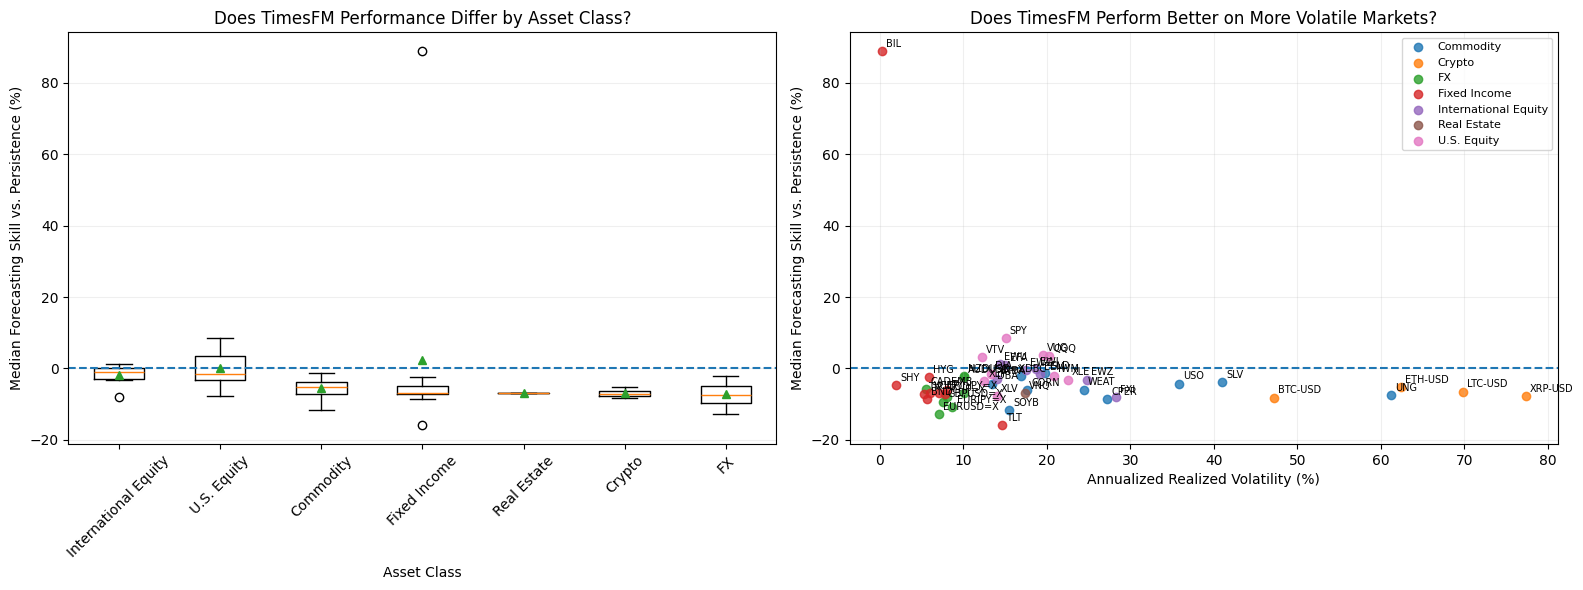

In [ ]:
# ============================================================
# K. WHAT EXPLAINS CROSS-ASSET FORECASTING PERFORMANCE?
#
# Hypothesis 1: performance differs across asset classes
# Hypothesis 2: performance is related to volatility
# ============================================================

from scipy.stats import spearmanr, kruskal


# ------------------------------------------------------------
# 1. COLLAPSE THE 25 EXPERIMENTAL CONDITIONS
#
# Give every asset one primary outcome:
# median forecasting skill across all
# 5 lookbacks × 5 forecast horizons.
# ------------------------------------------------------------

asset_profile = (
    asset_scores
    .groupby([
        "Ticker",
        "Asset",
        "Asset Class"
    ])
    .agg(
        Overall_Median_Skill=("Skill", "median"),
        Overall_Mean_Skill=("Skill", "mean"),

        Positive_Config_Share=(
            "Skill",
            lambda x: (x > 0).mean()
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 2. CALCULATE VOLATILITY OVER THE SAME EVALUATION ERA
#
# Use the common market-day calendar so volatility
# is defined consistently across all 50 assets.
# ------------------------------------------------------------

evaluation_start = (
    replication_results["Forecast Origin"].min()
)

evaluation_end = (
    replication_results["Target Date"].max()
)

evaluation_prices = balanced_prices.loc[
    evaluation_start:evaluation_end
]

log_returns = np.log(
    evaluation_prices /
    evaluation_prices.shift(1)
)

# Annualized realized volatility.
# Because everything has been placed on our shared
# market-day calendar, use 252 observations per year.
annualized_volatility = (
    log_returns.std() * np.sqrt(252)
)

volatility_table = (
    annualized_volatility
    .rename("Annualized_Volatility")
    .reset_index()
    .rename(columns={"index": "Ticker"})
)

asset_profile = asset_profile.merge(
    volatility_table,
    on="Ticker",
    how="left"
)


# ------------------------------------------------------------
# 3. ASSET-CLASS SUMMARY
# ------------------------------------------------------------

class_summary = (
    asset_profile
    .groupby("Asset Class")
    .agg(
        Assets=("Ticker", "size"),

        Median_Overall_Skill=(
            "Overall_Median_Skill",
            "median"
        ),

        Mean_Overall_Skill=(
            "Overall_Median_Skill",
            "mean"
        ),

        Median_Volatility=(
            "Annualized_Volatility",
            "median"
        ),

        Assets_Positive=(
            "Overall_Median_Skill",
            lambda x: (x > 0).mean()
        )
    )
    .reset_index()
    .sort_values(
        "Median_Overall_Skill",
        ascending=False
    )
)


# Pretty display version
class_display = class_summary.copy()

class_display["Median Skill %"] = (
    class_display["Median_Overall_Skill"] * 100
).round(1)

class_display["Mean Skill %"] = (
    class_display["Mean_Overall_Skill"] * 100
).round(1)

class_display["Median Volatility %"] = (
    class_display["Median_Volatility"] * 100
).round(1)

class_display["Assets With Positive Median Skill %"] = (
    class_display["Assets_Positive"] * 100
).round(0)

print("Performance by asset class:\n")

display(
    class_display[[
        "Asset Class",
        "Assets",
        "Median Skill %",
        "Mean Skill %",
        "Median Volatility %",
        "Assets With Positive Median Skill %"
    ]]
)


# ------------------------------------------------------------
# 4. VOLATILITY RELATIONSHIP
#
# Spearman correlation asks whether higher volatility
# is monotonically associated with higher/lower skill
# without assuming a linear relationship.
# ------------------------------------------------------------

rho, volatility_p = spearmanr(
    asset_profile["Annualized_Volatility"],
    asset_profile["Overall_Median_Skill"]
)

print("\nVolatility hypothesis:")
print(f"Spearman correlation: {rho:+.3f}")
print(f"Exploratory p-value:  {volatility_p:.4f}")


# ------------------------------------------------------------
# 5. ASSET-CLASS DIFFERENCE TEST
#
# Kruskal-Wallis is a simple non-parametric screen asking
# whether the distributions appear different across classes.
#
# Exclude groups with only one asset from the formal test.
# They remain visible in the descriptive table and plots.
# ------------------------------------------------------------

class_groups = []

class_names_for_test = []

for asset_class, group in asset_profile.groupby(
    "Asset Class"
):

    if len(group) >= 2:

        class_groups.append(
            group["Overall_Median_Skill"].values
        )

        class_names_for_test.append(asset_class)


kw_stat, class_p = kruskal(*class_groups)

print("\nAsset-class hypothesis:")
print(
    "Classes included:",
    ", ".join(class_names_for_test)
)

print(f"Kruskal-Wallis statistic: {kw_stat:.3f}")
print(f"Exploratory p-value:      {class_p:.4f}")


# ------------------------------------------------------------
# 6. PRETTY ASSET-LEVEL TABLE
# ------------------------------------------------------------

asset_profile_display = asset_profile.copy()

asset_profile_display["Median Skill %"] = (
    asset_profile_display[
        "Overall_Median_Skill"
    ] * 100
).round(1)

asset_profile_display["Volatility %"] = (
    asset_profile_display[
        "Annualized_Volatility"
    ] * 100
).round(1)

asset_profile_display[
    "Positive Configurations %"
] = (
    asset_profile_display[
        "Positive_Config_Share"
    ] * 100
).round(0)

asset_profile_display = (
    asset_profile_display
    .sort_values(
        "Overall_Median_Skill",
        ascending=False
    )
)

print("\nIndividual assets, ranked by overall forecasting skill:\n")

display(
    asset_profile_display[[
        "Ticker",
        "Asset",
        "Asset Class",
        "Median Skill %",
        "Volatility %",
        "Positive Configurations %"
    ]]
)


# ============================================================
# 7. VISUALIZE BOTH HYPOTHESES SIDE BY SIDE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# ------------------------------------------------------------
# LEFT: DISTRIBUTION OF SKILL BY ASSET CLASS
# ------------------------------------------------------------

class_order = (
    class_summary["Asset Class"]
    .tolist()
)

class_skill_data = [
    (
        asset_profile.loc[
            asset_profile["Asset Class"] == asset_class,
            "Overall_Median_Skill"
        ] * 100
    ).values

    for asset_class in class_order
]

axes[0].boxplot(
    class_skill_data,
    labels=class_order,
    showmeans=True
)

axes[0].axhline(
    0,
    linestyle="--"
)

axes[0].set_ylabel(
    "Median Forecasting Skill vs. Persistence (%)"
)

axes[0].set_xlabel(
    "Asset Class"
)

axes[0].set_title(
    "Does TimesFM Performance Differ by Asset Class?"
)

axes[0].tick_params(
    axis="x",
    rotation=45
)

axes[0].grid(
    axis="y",
    alpha=0.2
)


# ------------------------------------------------------------
# RIGHT: VOLATILITY VS. FORECASTING SKILL
#
# Plot each class separately so class membership remains
# visible while we inspect the volatility relationship.
# ------------------------------------------------------------

for asset_class, group in asset_profile.groupby(
    "Asset Class"
):

    axes[1].scatter(
        group["Annualized_Volatility"] * 100,
        group["Overall_Median_Skill"] * 100,
        label=asset_class,
        alpha=0.8
    )

    # Label individual markets
    for _, row in group.iterrows():

        axes[1].annotate(
            row["Ticker"],
            (
                row["Annualized_Volatility"] * 100,
                row["Overall_Median_Skill"] * 100
            ),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7
        )


axes[1].axhline(
    0,
    linestyle="--"
)

axes[1].set_xlabel(
    "Annualized Realized Volatility (%)"
)

axes[1].set_ylabel(
    "Median Forecasting Skill vs. Persistence (%)"
)

axes[1].set_title(
    "Does TimesFM Perform Better on More Volatile Markets?"
)

axes[1].legend(
    fontsize=8
)

axes[1].grid(
    alpha=0.2
)


plt.tight_layout()
plt.show()

### First look at the hypotheses

The cross-asset variation does appear to have structure, but one extreme result immediately requires caution. BIL, the Treasury-bill ETF, shows nearly 90% forecasting skill despite having almost no realized volatility. Because our skill measure expresses TimesFM's error as an improvement over persistence, it can become unstable when the persistence error itself is extremely small. A large percentage improvement on an almost motionless asset may correspond to a trivially small difference in actual price error.

Setting that anomaly aside, the asset-class picture is suggestive. U.S. equities appear strongest overall, with many assets clustered near or above zero skill. International equities perform somewhat worse, while commodities, foreign exchange, and cryptocurrencies are generally negative. Fixed income is also mostly negative apart from the BIL outlier.

The volatility hypothesis is less obvious. The highest-volatility assets — particularly cryptocurrencies — tend to perform poorly, but among the much larger cluster of markets with moderate volatility there is no clear visual relationship between volatility and TimesFM skill. This raises the possibility that apparent volatility effects may actually reflect differences between asset classes rather than volatility itself.

Before treating either hypothesis statistically, we should diagnose the BIL result and repeat the volatility analysis with and without extremely low-movement assets. That will tell us whether the apparent relationships are genuine or artifacts of the relative skill metric.

Largest positive and negative skill values:



,Ticker,Asset,Asset Class,Median Skill %,Volatility %,Typical Persistence Error %
1,BIL,U.S. Treasury Bills,Fixed Income,88.954230,0.244217,0.364690
36,SPY,S&P 500,U.S. Equity,8.400794,15.051399,2.501682
44,VUG,U.S. Growth Stocks,U.S. Equity,3.863190,19.549338,3.456396
32,QQQ,Nasdaq 100,U.S. Equity,3.464444,20.295616,3.224746
43,VTV,U.S. Value Stocks,U.S. Equity,3.101475,12.251623,1.997597
19,EWU,United Kingdom,International Equity,1.187474,14.377074,1.987650
12,EFA,Developed Markets ex-U.S.,International Equity,1.028809,15.021253,2.163771
18,EWJ,Japan,International Equity,-0.281412,18.707877,2.361575
17,EWG,Germany,International Equity,-0.487151,17.443752,2.321872
23,GLD,Gold,Commodity,-1.342074,19.781672,2.715971



All 50 assets:
Spearman rho = +0.069
p-value      = 0.6335

Excluding BIL:
Spearman rho = +0.136
p-value      = 0.3518


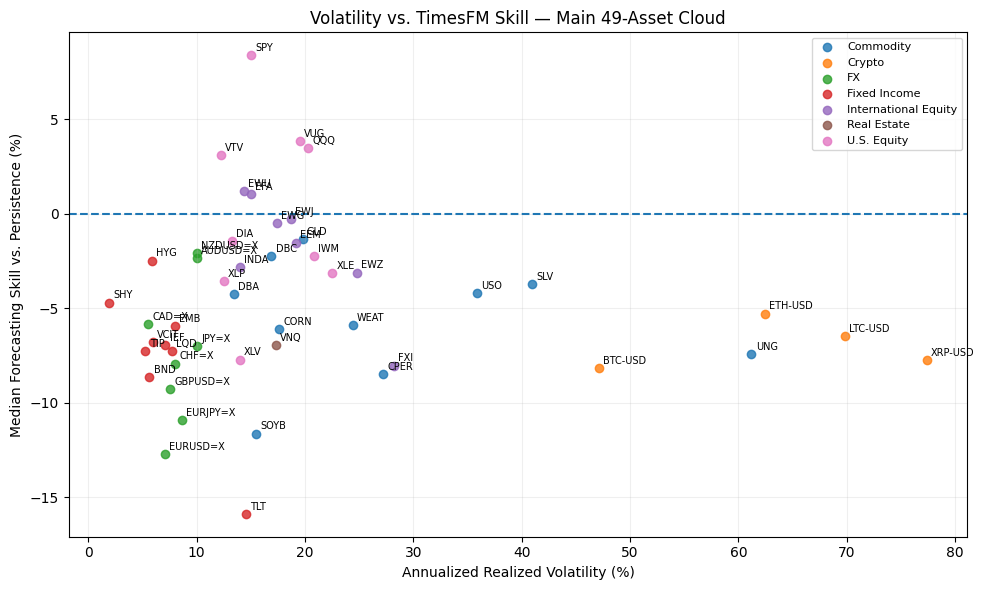

In [ ]:
# ============================================================
# K. DIAGNOSE LOW-MOVEMENT ASSETS AND RECHECK VOLATILITY
# ============================================================

# First calculate each asset's typical persistence error
# as a percentage of its price. This tells us how much the
# asset actually moves over the forecasting experiment.

r["Persistence Error %"] = (
    r["Persistence Error"] /
    r["Last Known Price"]
)

movement_profile = (
    r.groupby(["Ticker", "Asset", "Asset Class"])
    .agg(
        Median_Persistence_Error_Pct=(
            "Persistence Error %",
            "median"
        ),
        Mean_Persistence_Error_Pct=(
            "Persistence Error %",
            "mean"
        )
    )
    .reset_index()
)

diagnostic = asset_profile.merge(
    movement_profile,
    on=["Ticker", "Asset", "Asset Class"],
    how="left"
)

diagnostic["Median Skill %"] = (
    diagnostic["Overall_Median_Skill"] * 100
)

diagnostic["Volatility %"] = (
    diagnostic["Annualized_Volatility"] * 100
)

diagnostic["Typical Persistence Error %"] = (
    diagnostic["Median_Persistence_Error_Pct"] * 100
)


# ------------------------------------------------------------
# SHOW THE MOST EXTREME SKILL RESULTS
# ------------------------------------------------------------

print("Largest positive and negative skill values:\n")

display(
    diagnostic[
        [
            "Ticker",
            "Asset",
            "Asset Class",
            "Median Skill %",
            "Volatility %",
            "Typical Persistence Error %"
        ]
    ]
    .sort_values(
        "Median Skill %",
        ascending=False
    )
    .head(10)
)


# ------------------------------------------------------------
# VOLATILITY CORRELATION: ALL ASSETS
# ------------------------------------------------------------

rho_all, p_all = spearmanr(
    diagnostic["Annualized_Volatility"],
    diagnostic["Overall_Median_Skill"]
)

print("\nAll 50 assets:")
print(f"Spearman rho = {rho_all:+.3f}")
print(f"p-value      = {p_all:.4f}")


# ------------------------------------------------------------
# VOLATILITY CORRELATION: EXCLUDING BIL
#
# This is a diagnostic sensitivity analysis, not a replacement
# for the original result.
# ------------------------------------------------------------

without_bil = diagnostic[
    diagnostic["Ticker"] != "BIL"
].copy()

rho_no_bil, p_no_bil = spearmanr(
    without_bil["Annualized_Volatility"],
    without_bil["Overall_Median_Skill"]
)

print("\nExcluding BIL:")
print(f"Spearman rho = {rho_no_bil:+.3f}")
print(f"p-value      = {p_no_bil:.4f}")


# ------------------------------------------------------------
# RE-PLOT WITHOUT BIL SO WE CAN SEE THE MAIN CLOUD
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for asset_class, group in without_bil.groupby("Asset Class"):

    plt.scatter(
        group["Volatility %"],
        group["Median Skill %"],
        label=asset_class,
        alpha=0.8
    )

    for _, row in group.iterrows():

        plt.annotate(
            row["Ticker"],
            (
                row["Volatility %"],
                row["Median Skill %"]
            ),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7
        )

plt.axhline(0, linestyle="--")

plt.xlabel("Annualized Realized Volatility (%)")
plt.ylabel("Median Forecasting Skill vs. Persistence (%)")

plt.title(
    "Volatility vs. TimesFM Skill — Main 49-Asset Cloud"
)

plt.legend(fontsize=8)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Does TimesFM work differently across asset classes, forecast horizons, and lookback windows?

The previous summaries necessarily compressed some of the experiment. But our replication actually varied three dimensions simultaneously: **what kind of market TimesFM was forecasting, how much historical context it received, and how far into the future the forecast was evaluated**.

Those dimensions may interact. An asset class might appear unforecastable on average while becoming relatively predictable at a particular horizon and lookback. For example, equities might benefit from several years of historical context when forecasting months ahead, while currencies might behave differently at shorter horizons.

We therefore return to the complete experiment rather than collapsing across lookbacks. For every asset class, we calculate median forecasting skill separately for each combination of the five lookback windows and five forecast horizons.

Because three-dimensional tables are difficult to interpret directly, we will display the result as a series of heatmaps. Each panel represents one lookback period; within each panel, rows are asset classes and columns are forecast horizons. This allows us to see whether particular regions of the experimental space consistently produce forecasting value.

In [ ]:
# ============================================================
# ASSET CLASS × LOOKBACK × FORECAST HORIZON
# ============================================================

class_grid_summary = (
    asset_scores
    .groupby([
        "Asset Class",
        "Lookback",
        "Lookback Days",
        "Horizon",
        "Days Ahead"
    ])
    .agg(
        Assets=("Ticker", "nunique"),

        Median_Skill=("Skill", "median"),

        Mean_Skill=("Skill", "mean"),

        Positive_Share=(
            "Skill",
            lambda x: (x > 0).mean()
        )
    )
    .reset_index()
)

lookback_order = [
    "3 Months",
    "6 Months",
    "1 Year",
    "2 Years",
    "5 Years"
]

horizon_order = [
    "1 Day",
    "1 Week",
    "1 Month",
    "3 Months",
    "6 Months"
]

# Order asset classes by overall median skill
class_order = (
    asset_scores
    .groupby("Asset Class")["Skill"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

print(
    "Grid cells:",
    len(class_grid_summary)
)

display(
    class_grid_summary
    .sort_values([
        "Lookback Days",
        "Asset Class",
        "Days Ahead"
    ])
    .head(20)
)

Grid cells: 175


,Asset Class,Lookback,Lookback Days,Horizon,Days Ahead,Assets,Median_Skill,Mean_Skill,Positive_Share
10,Commodity,3 Months,63,1 Day,1,10,-0.052907,-0.057290,0.100
12,Commodity,3 Months,63,1 Week,5,10,-0.166192,-0.179766,0.000
11,Commodity,3 Months,63,1 Month,20,10,-0.163047,-0.228747,0.000
13,Commodity,3 Months,63,3 Months,60,10,-0.215461,-0.226096,0.100
14,Commodity,3 Months,63,6 Months,120,10,-0.295296,-0.333512,0.100
35,Crypto,3 Months,63,1 Day,1,4,-0.110137,-0.109678,0.000
37,Crypto,3 Months,63,1 Week,5,4,-0.156259,-0.129872,0.000
36,Crypto,3 Months,63,1 Month,20,4,-0.247222,-0.231669,0.000
38,Crypto,3 Months,63,3 Months,60,4,-0.182460,-0.190662,0.000
39,Crypto,3 Months,63,6 Months,120,4,-0.378161,-0.448477,0.000


/tmp/ipykernel_618/961129251.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


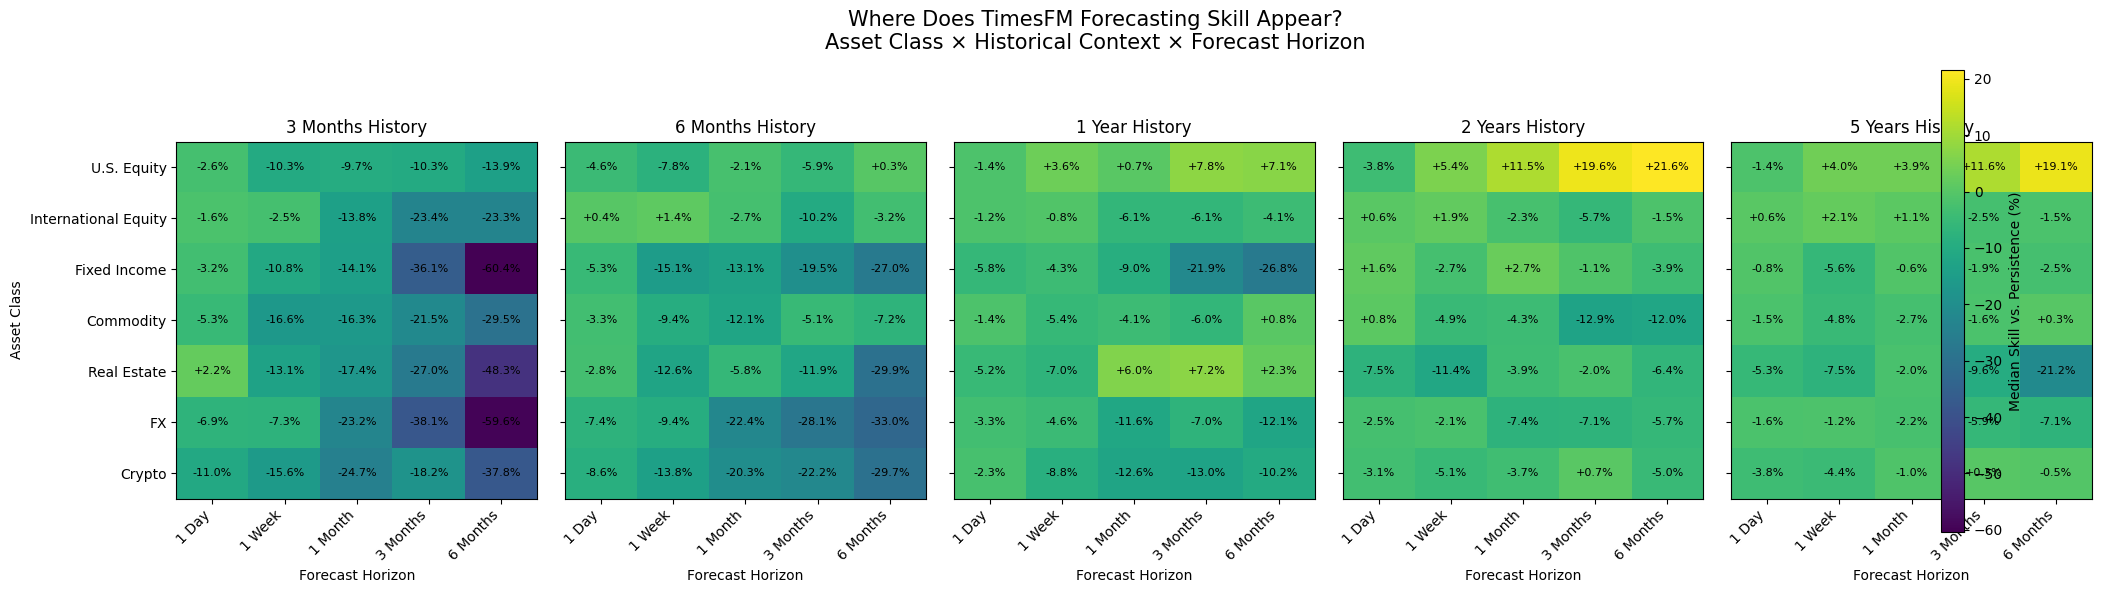

In [ ]:
# ============================================================
# FIVE-PANEL HEATMAP
# One panel for each LOOKBACK
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 6),
    sharey=True
)

# Use a common scale across all panels
all_skill_values = (
    class_grid_summary["Median_Skill"] * 100
)

vmin = all_skill_values.min()
vmax = all_skill_values.max()

images = []

for ax, lookback in zip(
    axes,
    lookback_order
):

    temp = (
        class_grid_summary[
            class_grid_summary["Lookback"] == lookback
        ]
        .pivot(
            index="Asset Class",
            columns="Horizon",
            values="Median_Skill"
        )
        .reindex(
            index=class_order,
            columns=horizon_order
        )
        * 100
    )

    image = ax.imshow(
        temp.values,
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    images.append(image)

    ax.set_xticks(
        range(len(horizon_order))
    )

    ax.set_xticklabels(
        horizon_order,
        rotation=45,
        ha="right"
    )

    ax.set_title(
        f"{lookback} History"
    )

    ax.set_xlabel(
        "Forecast Horizon"
    )

    # Write values into cells
    for i in range(temp.shape[0]):
        for j in range(temp.shape[1]):

            value = temp.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:+.1f}%",
                ha="center",
                va="center",
                fontsize=8
            )


# Y-axis labels only need to appear on the first panel
axes[0].set_yticks(
    range(len(class_order))
)

axes[0].set_yticklabels(
    class_order
)

axes[0].set_ylabel(
    "Asset Class"
)


# One shared colorbar for all five panels
fig.colorbar(
    images[0],
    ax=axes,
    label="Median Skill vs. Persistence (%)",
    fraction=0.02,
    pad=0.02
)

fig.suptitle(
    "Where Does TimesFM Forecasting Skill Appear?\n"
    "Asset Class × Historical Context × Forecast Horizon",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 0.96, 0.92]
)

plt.show()

### Which positive regions are statistically distinguishable from zero?

The heatmaps reveal several apparently positive regions, particularly for U.S. equities with longer historical contexts and longer forecast horizons. But positive medians can arise by chance, especially when examining many combinations.

We therefore add an exploratory significance test. Within each asset class, lookback, and forecast horizon, we test whether the distribution of asset-level forecasting skill is systematically greater than zero. We use a one-sided Wilcoxon signed-rank test and then correct for the large number of comparisons using the Benjamini–Hochberg false-discovery-rate procedure.

A star indicates a positive cell that remains significant after this multiple-testing correction. These tests should still be interpreted cautiously: assets within a class are correlated, and longer-horizon forecasts overlap in time. The purpose here is to identify especially promising regions of the experimental space for more rigorous follow-up.

Testable cells: 150
Positive cells significant at raw p < .05: 6
Positive cells surviving FDR q < .05: 0

No positive cells survive FDR q < .05.

Strongest nominal positive results:


,Asset Class,Lookback,Horizon,Assets,Median Skill %,p,FDR q
167,U.S. Equity,5 Years,1 Week,9,4.0,0.0098,1.0
169,U.S. Equity,5 Years,6 Months,9,19.1,0.0195,1.0
117,International Equity,5 Years,1 Week,8,2.1,0.0273,1.0
158,U.S. Equity,2 Years,3 Months,9,19.6,0.0273,1.0
156,U.S. Equity,2 Years,1 Month,9,11.5,0.0371,1.0
159,U.S. Equity,2 Years,6 Months,9,21.6,0.0488,1.0
116,International Equity,5 Years,1 Month,8,1.1,0.0547,1.0
81,Fixed Income,2 Years,1 Month,10,2.7,0.0801,1.0
80,Fixed Income,2 Years,1 Day,10,1.6,0.0801,1.0
152,U.S. Equity,1 Year,1 Week,9,3.6,0.0820,1.0


/tmp/ipykernel_618/3790277386.py:375: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


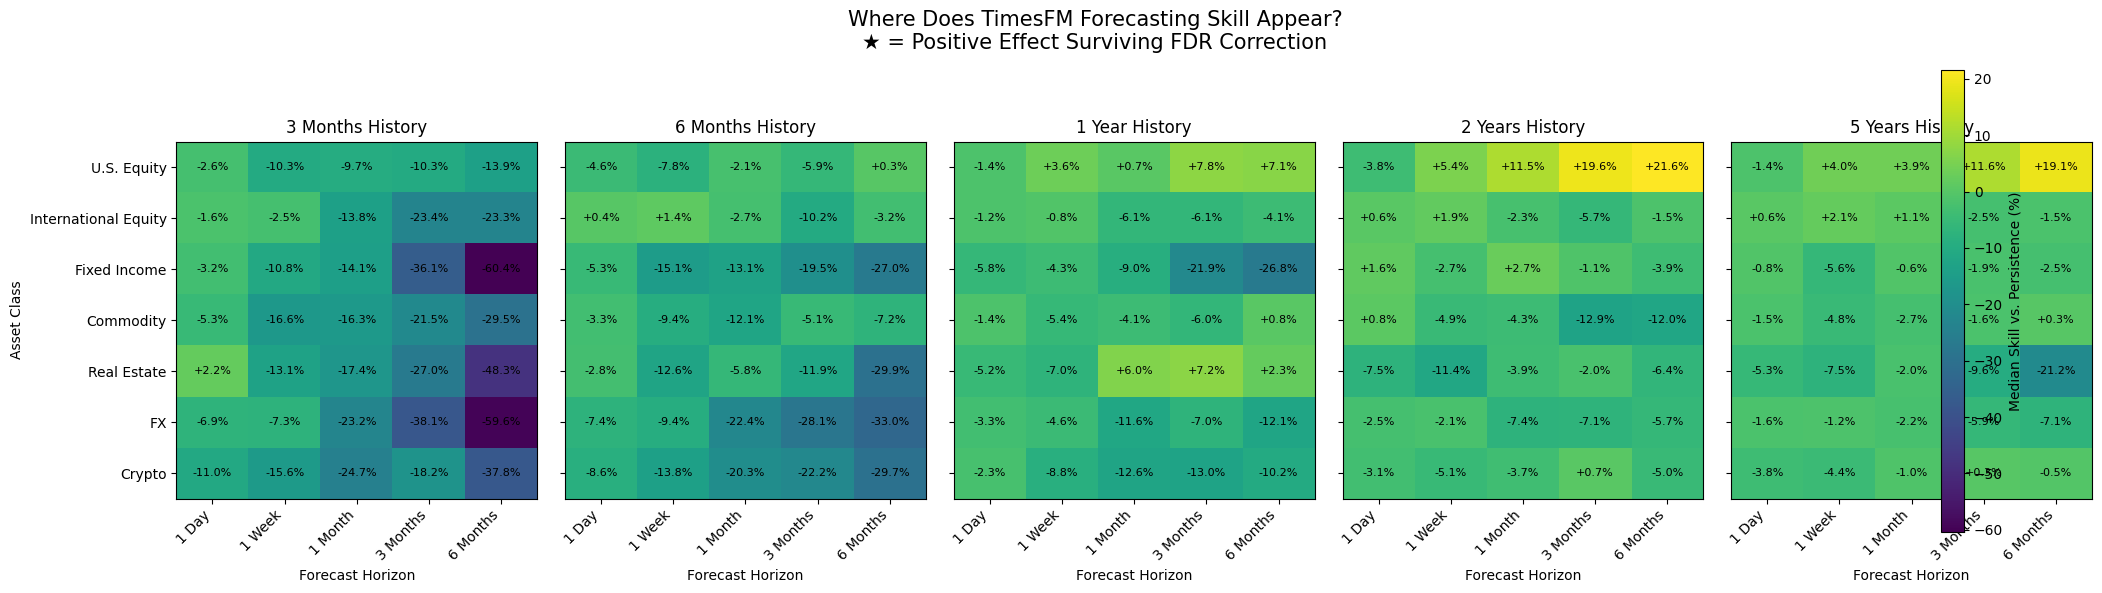

In [ ]:
# ============================================================
# SIGNIFICANCE SCREEN:
# Asset class × Lookback × Forecast horizon
# ============================================================

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# 1. ONE-SIDED TEST WITHIN EACH CELL
#
# H0: median asset-level skill <= 0
# H1: median asset-level skill > 0
#
# Unit here = asset.
# ------------------------------------------------------------

significance_rows = []

group_cols = [
    "Asset Class",
    "Lookback",
    "Lookback Days",
    "Horizon",
    "Days Ahead"
]

for keys, group in asset_scores.groupby(group_cols):

    (
        asset_class,
        lookback,
        lookback_days,
        horizon,
        days_ahead
    ) = keys

    skills = (
        group["Skill"]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .values
    )

    n_assets = len(skills)
    median_skill = np.median(skills) if n_assets else np.nan

    # We need multiple assets for a meaningful class-level test.
    # Real Estate, with one asset, will therefore remain untested.
    if n_assets >= 3 and not np.allclose(skills, 0):

        try:
            test = wilcoxon(
                skills,
                alternative="greater",
                zero_method="wilcox",
                method="auto"
            )

            p_value = test.pvalue

        except ValueError:
            p_value = np.nan

    else:
        p_value = np.nan


    significance_rows.append({
        "Asset Class": asset_class,
        "Lookback": lookback,
        "Lookback Days": lookback_days,
        "Horizon": horizon,
        "Days Ahead": days_ahead,
        "Assets": n_assets,
        "Median Skill": median_skill,
        "p_value": p_value
    })


significance_results = pd.DataFrame(significance_rows)


# ------------------------------------------------------------
# 2. MULTIPLE-TESTING CORRECTION
#
# Correct across ALL testable cells rather than treating
# each heatmap separately.
# ------------------------------------------------------------

significance_results["q_value"] = np.nan

testable = significance_results["p_value"].notna()

if testable.sum() > 0:

    reject, q_values, _, _ = multipletests(
        significance_results.loc[
            testable,
            "p_value"
        ],
        alpha=0.05,
        method="fdr_bh"
    )

    significance_results.loc[
        testable,
        "q_value"
    ] = q_values


# Significant POSITIVE effects only
significance_results["Significant Positive"] = (
    (significance_results["Median Skill"] > 0)
    &
    (significance_results["q_value"] < 0.05)
)


# Nominal significance, useful diagnostically
significance_results["Nominal Positive"] = (
    (significance_results["Median Skill"] > 0)
    &
    (significance_results["p_value"] < 0.05)
)


# ------------------------------------------------------------
# 3. SHOW WHAT SURVIVED
# ------------------------------------------------------------

survivors = (
    significance_results[
        significance_results["Significant Positive"]
    ]
    .sort_values("q_value")
    .copy()
)

print(
    "Testable cells:",
    testable.sum()
)

print(
    "Positive cells significant at raw p < .05:",
    significance_results["Nominal Positive"].sum()
)

print(
    "Positive cells surviving FDR q < .05:",
    significance_results["Significant Positive"].sum()
)


if len(survivors):

    survivors["Median Skill %"] = (
        survivors["Median Skill"] * 100
    ).round(1)

    survivors["p"] = (
        survivors["p_value"]
        .round(4)
    )

    survivors["FDR q"] = (
        survivors["q_value"]
        .round(4)
    )

    print("\nFDR-significant positive cells:\n")

    display(
        survivors[[
            "Asset Class",
            "Lookback",
            "Horizon",
            "Assets",
            "Median Skill %",
            "p",
            "FDR q"
        ]]
    )

else:

    print(
        "\nNo positive cells survive FDR q < .05."
    )

    print(
        "\nStrongest nominal positive results:"
    )

    nominal = (
        significance_results[
            significance_results[
                "Median Skill"
            ] > 0
        ]
        .sort_values("p_value")
        .head(12)
        .copy()
    )

    nominal["Median Skill %"] = (
        nominal["Median Skill"] * 100
    ).round(1)

    nominal["p"] = nominal["p_value"].round(4)
    nominal["FDR q"] = nominal["q_value"].round(4)

    display(
        nominal[[
            "Asset Class",
            "Lookback",
            "Horizon",
            "Assets",
            "Median Skill %",
            "p",
            "FDR q"
        ]]
    )


# ============================================================
# 4. RECREATE THE FIVE-PANEL HEATMAP WITH SIGNIFICANCE STARS
#
# ★ = positive and survives FDR q < .05
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 6),
    sharey=True
)

all_skill_values = (
    class_grid_summary["Median_Skill"] * 100
)

vmin = all_skill_values.min()
vmax = all_skill_values.max()

images = []


for ax, lookback in zip(
    axes,
    lookback_order
):

    skill_temp = (
        class_grid_summary[
            class_grid_summary["Lookback"] == lookback
        ]
        .pivot(
            index="Asset Class",
            columns="Horizon",
            values="Median_Skill"
        )
        .reindex(
            index=class_order,
            columns=horizon_order
        )
        * 100
    )


    sig_temp = (
        significance_results[
            significance_results["Lookback"] == lookback
        ]
        .pivot(
            index="Asset Class",
            columns="Horizon",
            values="Significant Positive"
        )
        .reindex(
            index=class_order,
            columns=horizon_order
        )
    )


    image = ax.imshow(
        skill_temp.values,
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    images.append(image)

    ax.set_xticks(
        range(len(horizon_order))
    )

    ax.set_xticklabels(
        horizon_order,
        rotation=45,
        ha="right"
    )

    ax.set_title(
        f"{lookback} History"
    )

    ax.set_xlabel(
        "Forecast Horizon"
    )


    # --------------------------------------------------------
    # WRITE VALUE + SIGNIFICANCE STAR
    # --------------------------------------------------------

    for i in range(skill_temp.shape[0]):

        for j in range(skill_temp.shape[1]):

            value = skill_temp.iloc[i, j]

            significant = (
                sig_temp.iloc[i, j]
                if pd.notna(sig_temp.iloc[i, j])
                else False
            )

            label = f"{value:+.1f}%"

            if significant:
                label += "\n★"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=8
            )


axes[0].set_yticks(
    range(len(class_order))
)

axes[0].set_yticklabels(
    class_order
)

axes[0].set_ylabel(
    "Asset Class"
)


fig.colorbar(
    images[0],
    ax=axes,
    label="Median Skill vs. Persistence (%)",
    fraction=0.02,
    pad=0.02
)

fig.suptitle(
    "Where Does TimesFM Forecasting Skill Appear?\n"
    "★ = Positive Effect Surviving FDR Correction",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 0.96, 0.92]
)

plt.show()

### What did the significance test add?

The significance test sharpens the distinction between an interesting pattern and a reliable result.

Across the 150 testable asset-class × lookback × forecast-horizon combinations, six positive cells reached the conventional \(p < .05\) threshold before correcting for multiple comparisons. Most of these were concentrated in the region that already looked most promising visually: U.S. equities with longer historical contexts. For example, the two-year lookback produced median forecasting improvements of roughly 12% at one month, 20% at three months, and 22% at six months, while the five-year lookback produced a roughly 19% improvement at six months.

But we examined many possible combinations. Once the full set of tests was corrected using the Benjamini–Hochberg false-discovery-rate procedure, **none of the positive effects remained statistically significant**.

This does not demonstrate that every apparent advantage is exactly zero. Rather, it means that the present experiment does not provide sufficiently strong evidence to distinguish any of these positive regions from chance after accounting for the breadth of the search.

The U.S.-equity pattern therefore remains suggestive rather than established. Its coherence across neighboring lookbacks and horizons makes it a reasonable hypothesis for a future confirmatory test, but it should not be treated as evidence that TimesFM has demonstrated a reliable forecasting advantage in that region.

There is also an important limitation to the test itself. Assets within each class are correlated — nine U.S. equity ETFs are not nine fully independent experiments — and longer-horizon forecast windows overlap through time. The Wilcoxon analysis is therefore best understood as an exploratory significance screen rather than the final word on statistical inference.

### **Conclusion:** What does the broader experiment tell us?

The broader replication substantially changes how we should interpret the promising results from the initial S&P 500 experiment.

Across 50 heterogeneous financial markets, TimesFM-3 did not demonstrate a robust zero-shot forecasting advantage over a simple persistence baseline. For the median asset, TimesFM underperformed persistence across every combination of historical context and forecast horizon we tested. Its directional forecasts also failed to outperform simple asset-specific directional baselines.

The failures were not completely uniform. Descriptively, performance varied considerably across lookback lengths, forecast horizons, and asset classes. Short historical contexts generally performed poorly, while longer contexts tended to reduce the model's disadvantage. The most promising region appeared among U.S. equities at medium and long forecast horizons, particularly when TimesFM received several years of historical context.

But the distinction between an interesting pattern and an established effect matters. Several of these U.S.-equity configurations were nominally significant before correcting for the large number of comparisons in the experiment, yet none remained statistically significant after false-discovery-rate correction. The apparent U.S.-equity advantage should therefore be treated as a hypothesis for future confirmatory testing, not as evidence of a reliable forecasting edge.

The evidence from this experiment therefore does not support the claim that pretrained, zero-shot TimesFM-3 is generally superior to simple statistical baselines for financial price forecasting. In this setting, assuming that the current price persists remains remarkably difficult to beat.

That negative result is itself informative. A time-series foundation model can perform impressively on a single financial series while failing to generalize across substantially different markets. The initial SPY result was therefore not the conclusion of the evaluation; it was the reason to broaden it.

More broadly, this experiment illustrates why model evaluation should expand around surprising successes rather than stop at them. A compelling result on one dataset, asset, or parameter configuration may reflect genuine capability, but it may also reflect a favorable corner of the evaluation space. Replication across different markets, horizons, context lengths, and statistical baselines substantially weakened the original claim.

The remaining question is different from the one this notebook set out to answer. Weak zero-shot transfer does not imply that TimesFM cannot learn financial structure through adaptation. It leaves open a second question: **how much can targeted post-training improve the pretrained model, and does that post-trainability differ across kinds of financial time series?**

That is a separate experiment.